<a href="https://colab.research.google.com/github/DHRUVPAWAR12/Capricorn/blob/main/Research_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
import pandas as pd

sheet_id = "1rC0XJhZ5Ti3mwMRBWrTdqtxKHo1pEdfUTWbi3U_aBvA"

url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv"

df = pd.read_csv(url)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 128
Columns: 29


In [16]:
print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicates")
print(df.duplicated().sum())


Missing Values
Timestamp                                                                                   0
What is your current role?                                                                  0
How many years of professional experience do you have?                                      0
Which function do you primarily work in?                                                    0
Which industry does your organization belong to?                                            0
Which Generative AI tool do you use most frequently?                                        0
How frequently do you use Generative AI in your work?                                       0
Approximately what percentage of your work activities are supported by AI?                  0
Which project management activities do you use AI for? (Select all that apply)              0
Generative AI reduces the effort required for project documentation.                        0
Generative AI improves the quality of projec

In [17]:
print("\nDescriptive Statistics")
print(df.describe())


Descriptive Statistics
       Generative AI accelerates meeting summary and MOM preparation.   \
count                                         128.000000                 
mean                                            4.328125                 
std                                             0.562746                 
min                                             3.000000                 
25%                                             4.000000                 
50%                                             4.000000                 
75%                                             5.000000                 
max                                             5.000000                 

       Generative AI improves decision-making speed.   \
count                                      128.000000   
mean                                         4.335938   
std                                          0.578858   
min                                          3.000000   
25%                     

In [ ]:
ROLE DISTRIBUTION

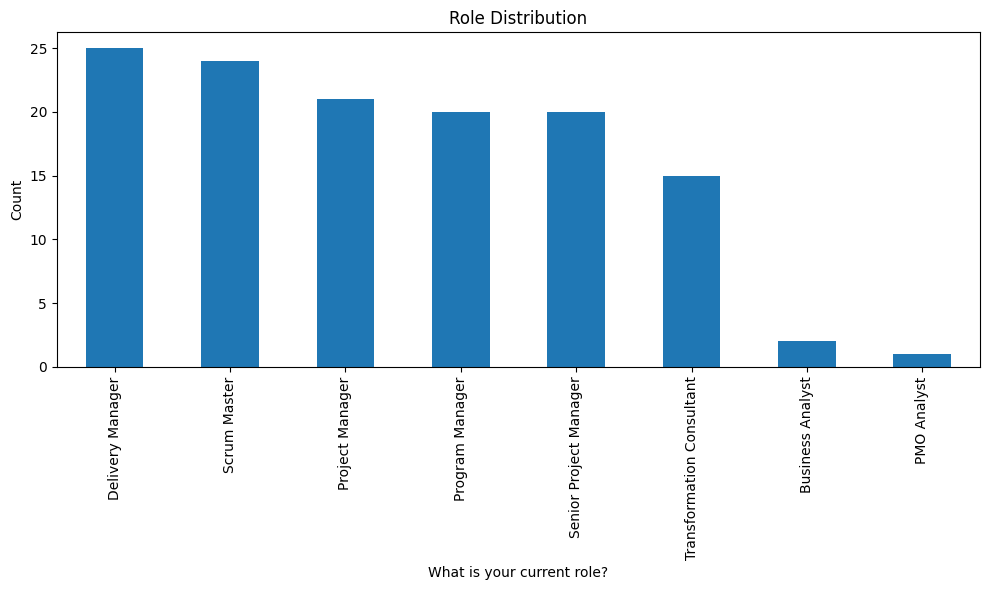

In [18]:
role_col = "What is your current role?"

plt.figure(figsize=(10,6))
df[role_col].value_counts().plot(kind='bar')
plt.title("Role Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

AI TOOL ADOPTION

In [21]:
for i, col in enumerate(df.columns):
    print(i, ":", col)

0 : Timestamp
1 : What is your current role?
2 : How many years of professional experience do you have? 
3 : Which function do you primarily work in? 
4 : Which industry does your organization belong to? 
5 : Which Generative AI tool do you use most frequently? 
6 : How frequently do you use Generative AI in your work? 
7 : Approximately what percentage of your work activities are supported by AI? 
8 : Which project management activities do you use AI for? (Select all that apply) 
9 : Generative AI reduces the effort required for project documentation. 
10 : Generative AI improves the quality of project reports and presentations. 
11 : Generative AI accelerates meeting summary and MOM preparation. 
12 : Generative AI improves decision-making speed. 
13 : Generative AI reduces repetitive administrative work. 
14 : Generative AI increases overall productivity. 
15 : Generative AI will significantly transform PMO and project delivery operations. 
16 : Generative AI improves stakeholder co

In [22]:
for col in df.columns:
    if "tool" in col.lower():
        print(col)

Which Generative AI tool do you use most frequently? 
I have concerns regarding confidentiality and data privacy when using AI tools. 


In [23]:
tool_col = "Which AI tool do you use most frequently?"

In [24]:
print(df.columns.tolist())

['Timestamp', 'What is your current role?', 'How many years of professional experience do you have? ', 'Which function do you primarily work in? ', 'Which industry does your organization belong to? ', 'Which Generative AI tool do you use most frequently? ', 'How frequently do you use Generative AI in your work? ', 'Approximately what percentage of your work activities are supported by AI? ', 'Which project management activities do you use AI for? (Select all that apply) ', 'Generative AI reduces the effort required for project documentation. ', 'Generative AI improves the quality of project reports and presentations. ', 'Generative AI accelerates meeting summary and MOM preparation. ', 'Generative AI improves decision-making speed. ', 'Generative AI reduces repetitive administrative work. ', 'Generative AI increases overall productivity. ', 'Generative AI will significantly transform PMO and project delivery operations. ', 'Generative AI improves stakeholder communication effectiveness

In [25]:
df.columns = df.columns.str.strip()

In [26]:
print(df.columns.tolist())

['Timestamp', 'What is your current role?', 'How many years of professional experience do you have?', 'Which function do you primarily work in?', 'Which industry does your organization belong to?', 'Which Generative AI tool do you use most frequently?', 'How frequently do you use Generative AI in your work?', 'Approximately what percentage of your work activities are supported by AI?', 'Which project management activities do you use AI for? (Select all that apply)', 'Generative AI reduces the effort required for project documentation.', 'Generative AI improves the quality of project reports and presentations.', 'Generative AI accelerates meeting summary and MOM preparation.', 'Generative AI improves decision-making speed.', 'Generative AI reduces repetitive administrative work.', 'Generative AI increases overall productivity.', 'Generative AI will significantly transform PMO and project delivery operations.', 'Generative AI improves stakeholder communication effectiveness.', 'Generativ

In [27]:
role_col = "What is your current role?"

tool_col = "Which Generative AI tool do you use most frequently?"

freq_col = "How frequently do you use Generative AI in your work?"

work_col = "Approximately what percentage of your work activities are supported by AI?"

time_saved_col = "Estimated Time Saved Per Week Using AI"

productivity_gain_col = "Estimated Productivity Improvement Due to AI"

In [28]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [29]:
print(df.shape)

(128, 27)


In [30]:
import plotly.express as px

tool_counts = (
    df[tool_col]
    .value_counts()
    .reset_index()
)

tool_counts.columns = ["Tool","Count"]

fig = px.treemap(
    tool_counts,
    path=["Tool"],
    values="Count",
    title="Generative AI Tool Adoption"
)

fig.show()

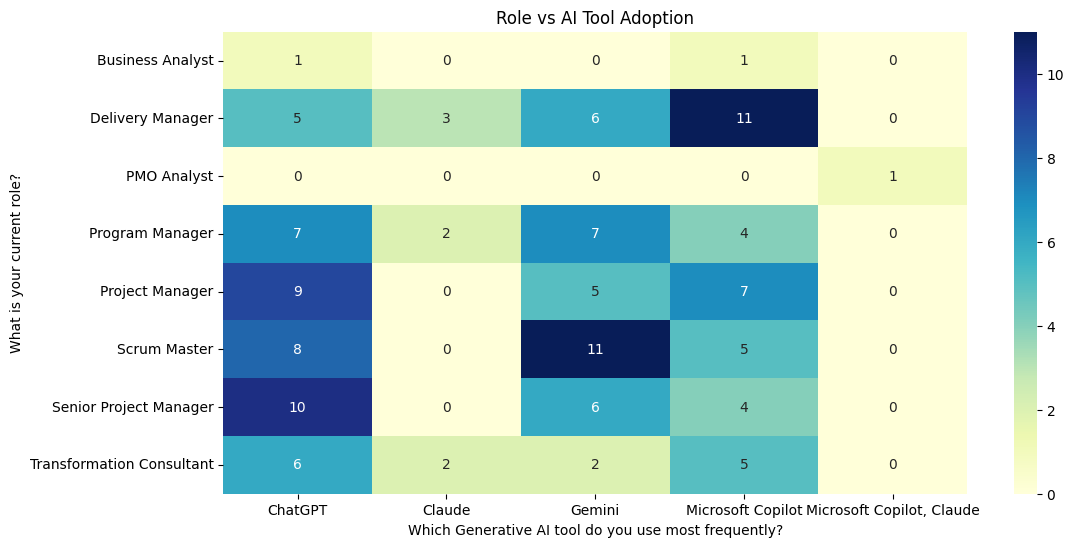

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

cross_tab = pd.crosstab(
    df[role_col],
    df[tool_col]
)

plt.figure(figsize=(12,6))

sns.heatmap(
    cross_tab,
    annot=True,
    cmap="YlGnBu"
)

plt.title("Role vs AI Tool Adoption")

plt.show()

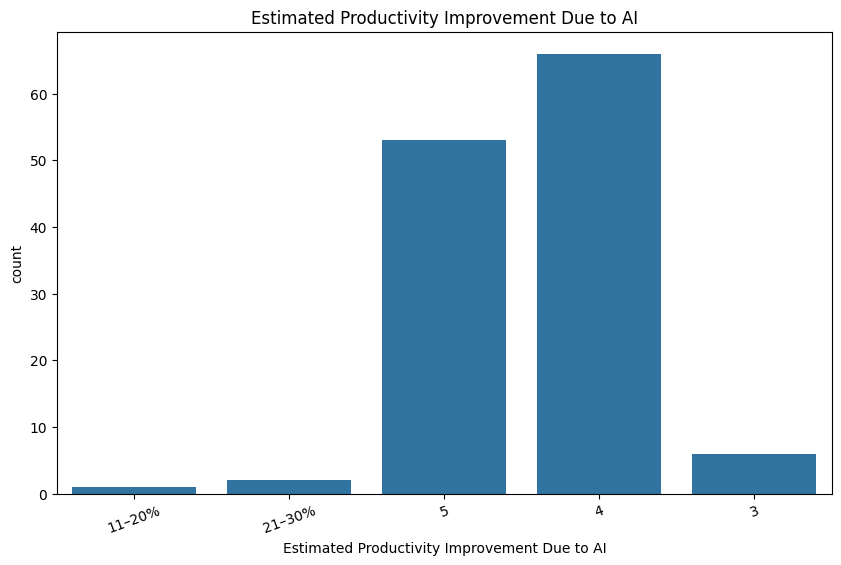

In [32]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x=productivity_gain_col
)

plt.title("Estimated Productivity Improvement Due to AI")

plt.xticks(rotation=20)

plt.show()

In [33]:
df.columns = df.columns.str.strip()

df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

print(df.shape)

(128, 27)


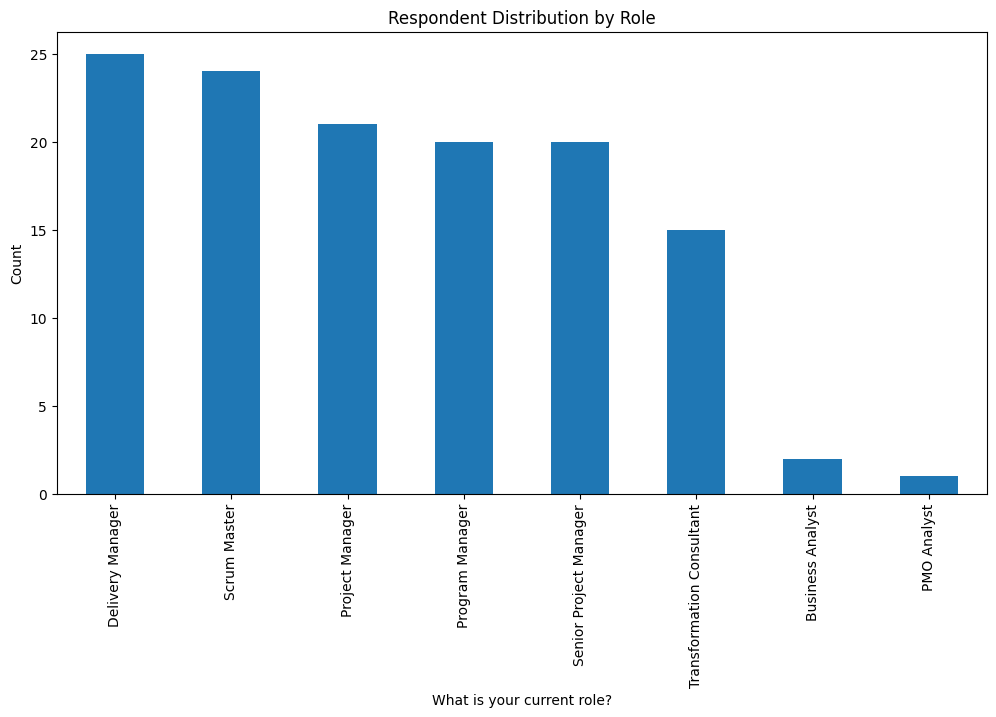

In [34]:
plt.figure(figsize=(12,6))

df[role_col].value_counts().plot(
    kind='bar'
)

plt.title("Respondent Distribution by Role")
plt.ylabel("Count")

plt.show()

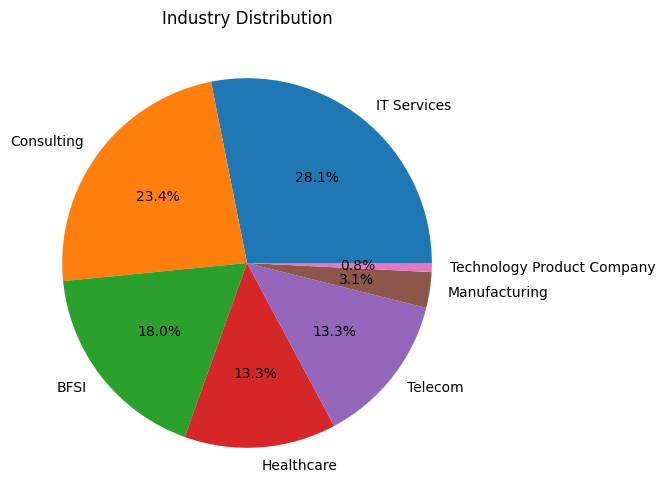

In [35]:
industry_col = "Which industry does your organization belong to?"

plt.figure(figsize=(10,6))

df[industry_col].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")
plt.title("Industry Distribution")

plt.show()

In [36]:
import plotly.express as px

tool_counts = (
    df[tool_col]
    .value_counts()
    .reset_index()
)

tool_counts.columns = [
    "Tool",
    "Count"
]

fig = px.treemap(
    tool_counts,
    path=["Tool"],
    values="Count",
    title="Generative AI Tool Adoption"
)

fig.show()

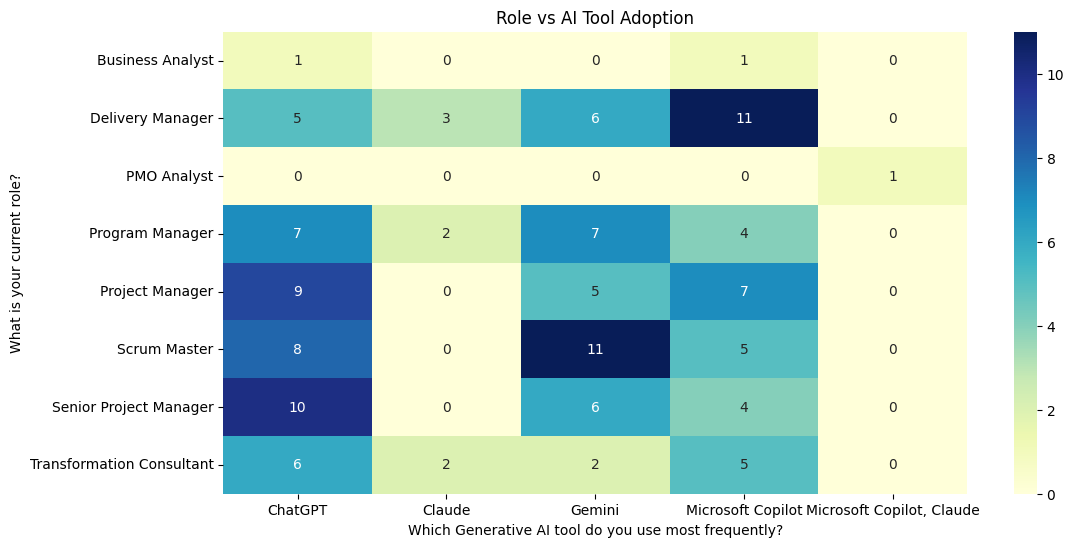

In [37]:
cross_tab = pd.crosstab(
    df[role_col],
    df[tool_col]
)

plt.figure(figsize=(12,6))

sns.heatmap(
    cross_tab,
    annot=True,
    cmap="YlGnBu"
)

plt.title(
    "Role vs AI Tool Adoption"
)

plt.show()

In [38]:
productivity_cols = [

"Generative AI reduces the effort required for project documentation.",

"Generative AI improves the quality of project reports and presentations.",

"Generative AI accelerates meeting summary and MOM preparation.",

"Generative AI improves decision-making speed.",

"Generative AI reduces repetitive administrative work.",

"Generative AI increases overall productivity.",

"Generative AI improves stakeholder communication effectiveness.",

"Generative AI positively impacts project delivery outcomes."

]

for c in productivity_cols:
    df[c] = pd.to_numeric(
        df[c],
        errors="coerce"
    )

df["Productivity_Index"] = (
    df[productivity_cols]
    .mean(axis=1)
)

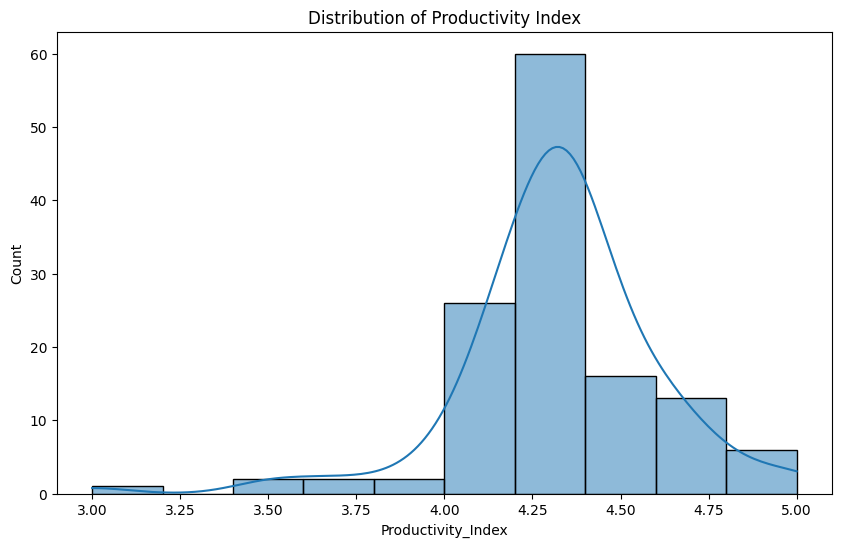

In [39]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Productivity_Index"],
    bins=10,
    kde=True
)

plt.title(
    "Distribution of Productivity Index"
)

plt.show()

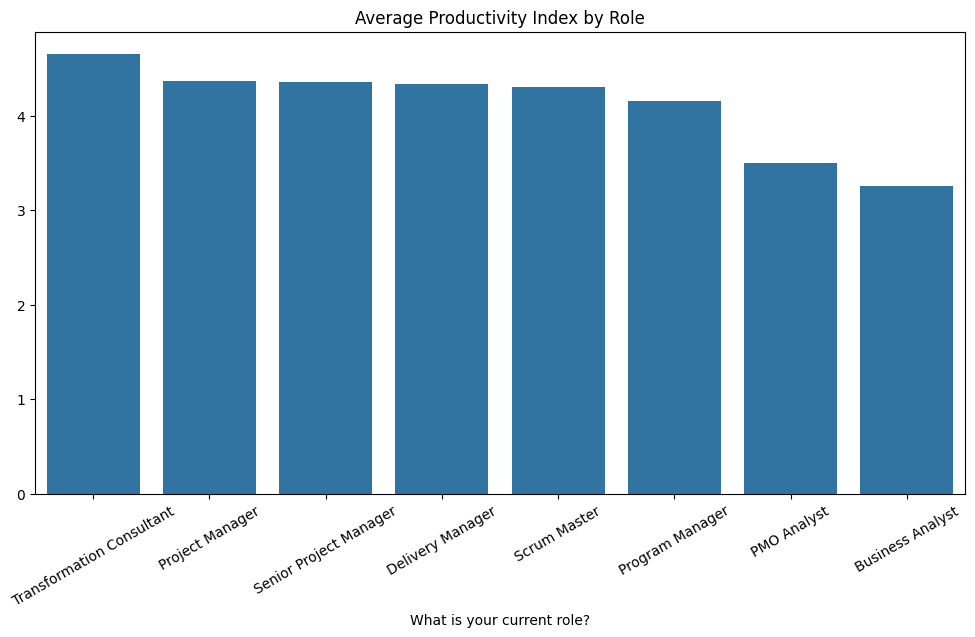

In [40]:
role_prod = (
    df.groupby(role_col)
    ["Productivity_Index"]
    .mean()
    .sort_values(
        ascending=False
    )
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=role_prod.index,
    y=role_prod.values
)

plt.xticks(rotation=30)

plt.title(
    "Average Productivity Index by Role"
)

plt.show()

In [41]:
governance_cols = [

"I have concerns regarding confidentiality and data privacy when using AI tools.",

"AI-generated outputs require validation before use",

"Lack of training limits effective adoption of AI.",

"My organization lacks a clear AI governance framework.",

"Over-reliance on AI may negatively impact critical thinking and professional judgment."

]

for c in governance_cols:
    df[c] = pd.to_numeric(
        df[c],
        errors="coerce"
    )

df["Governance_Index"] = (
    df[governance_cols]
    .mean(axis=1)
)

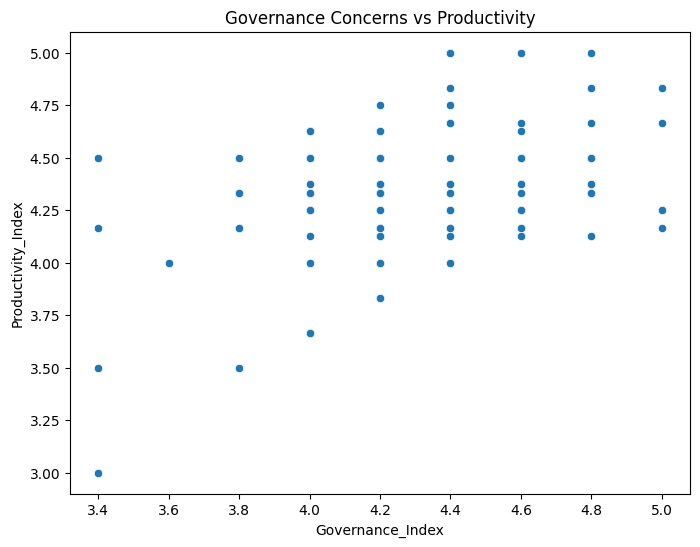

In [42]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Governance_Index",
    y="Productivity_Index"
)

plt.title(
    "Governance Concerns vs Productivity"
)

plt.show()

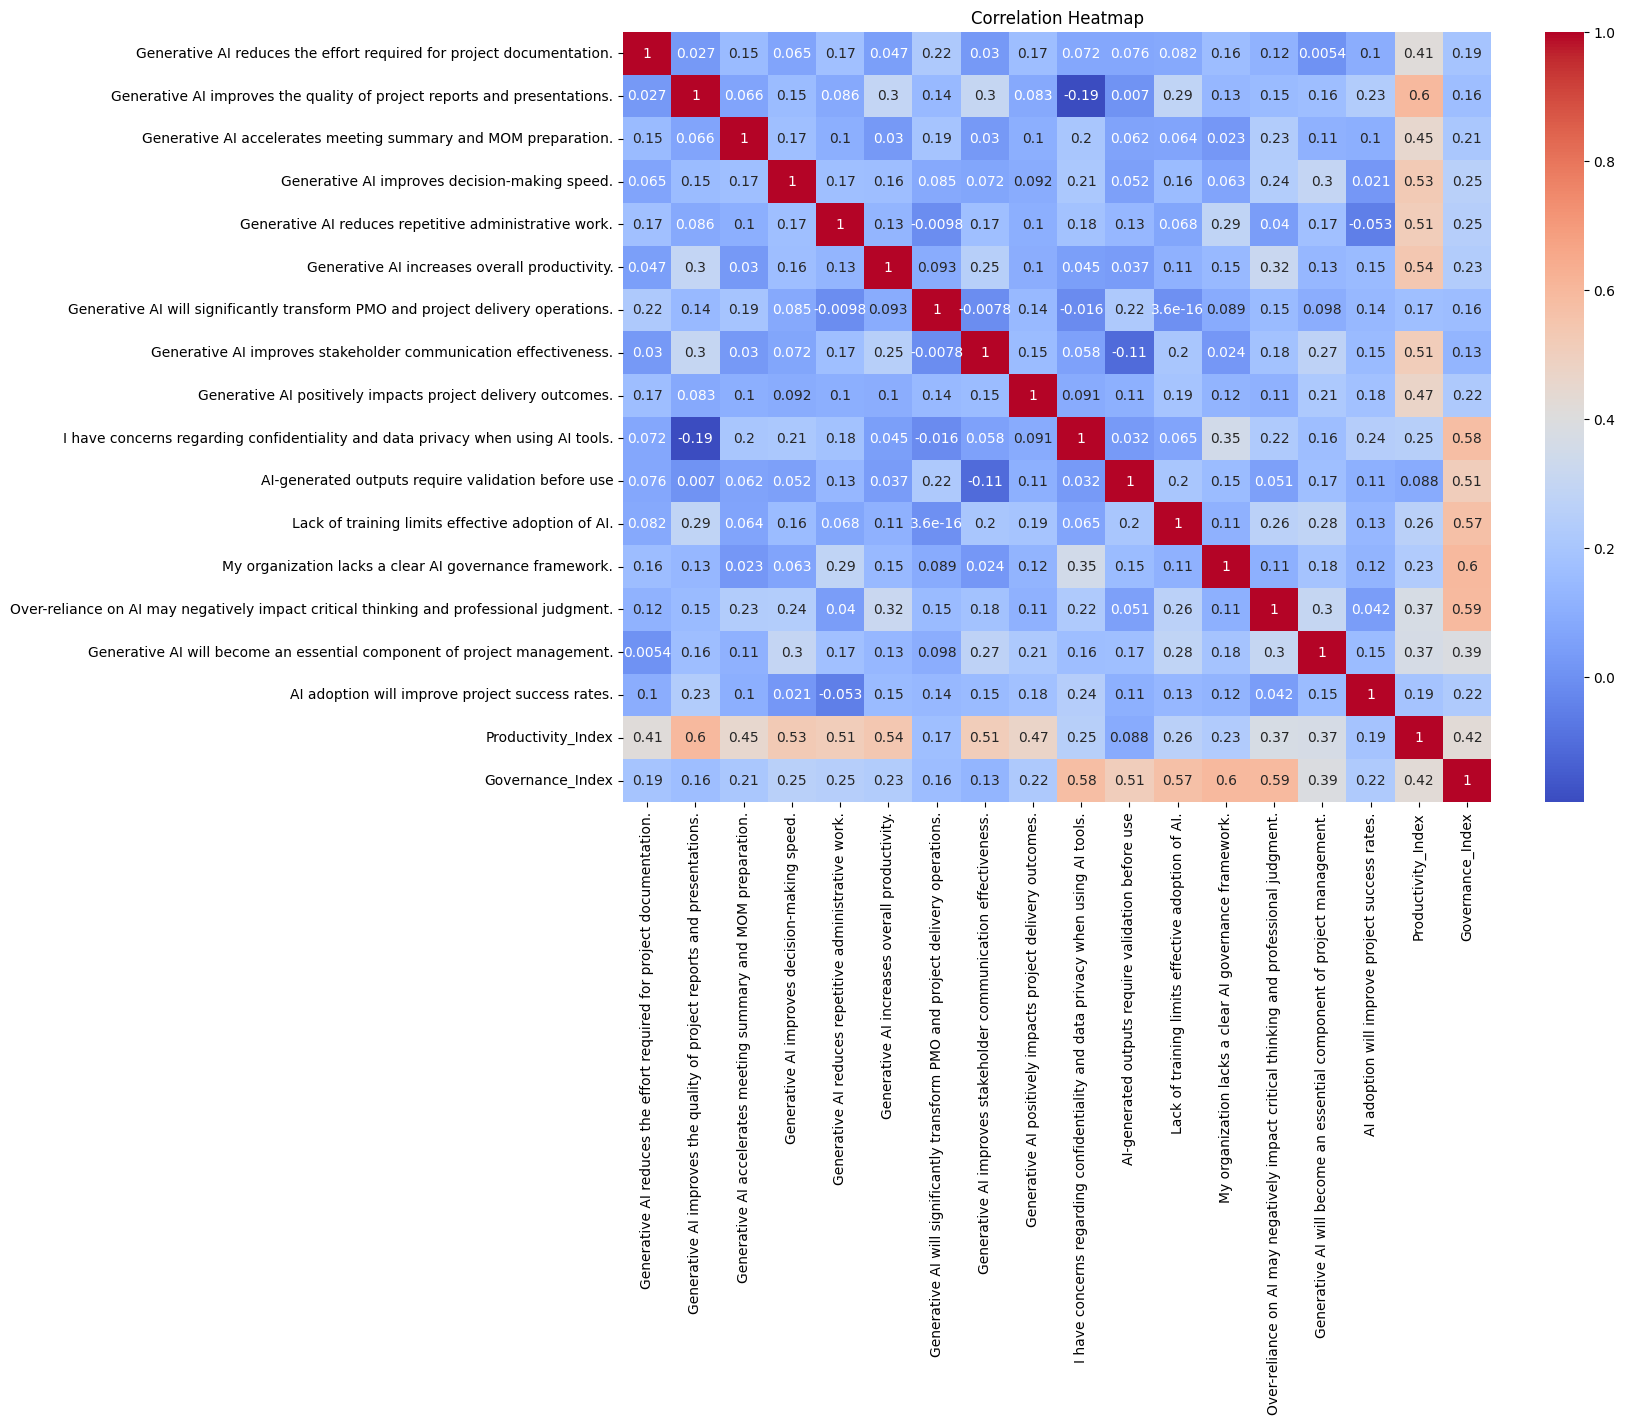

In [43]:
numeric_df = df.select_dtypes(
    include="number"
)

plt.figure(figsize=(14,10))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap"
)

plt.show()

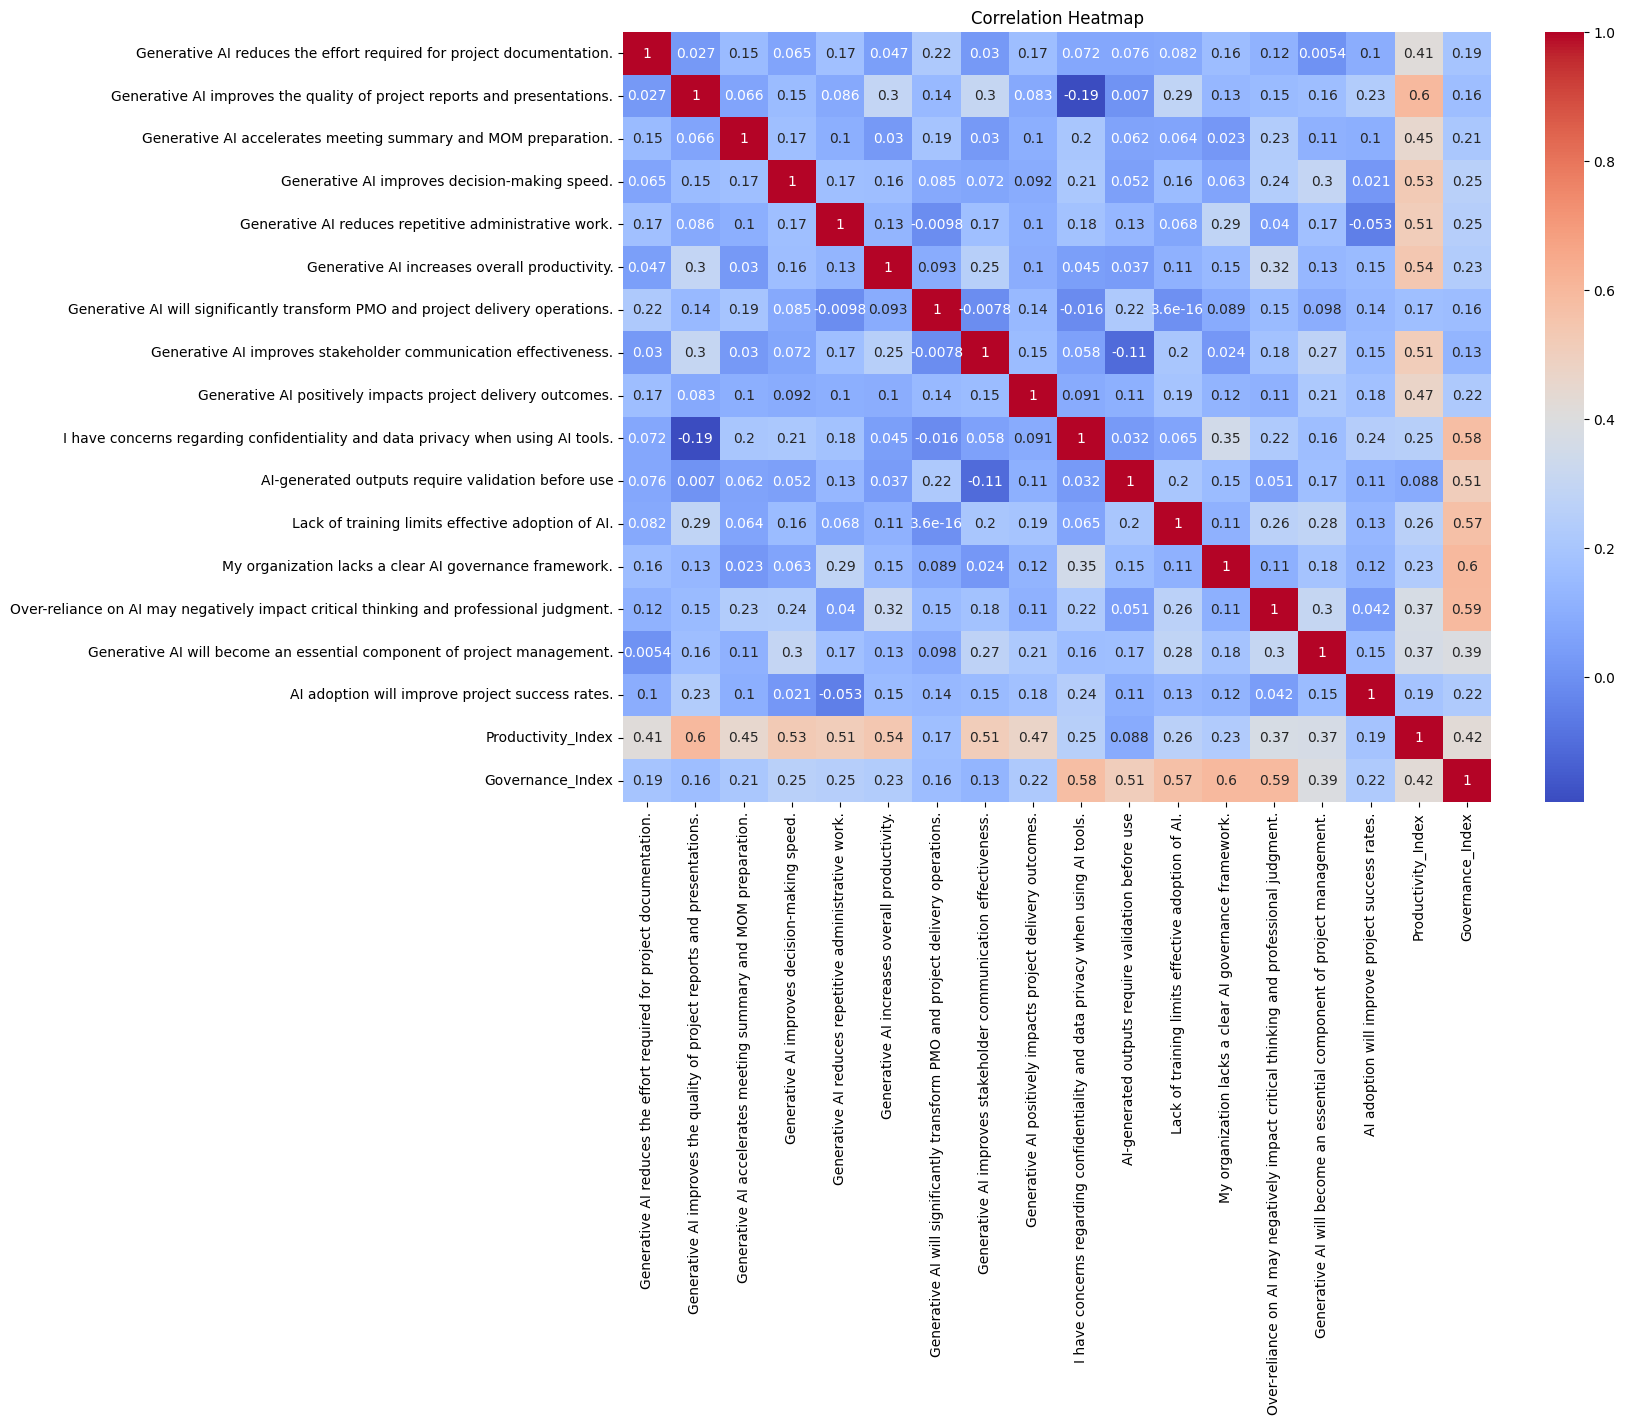

In [44]:
numeric_df = df.select_dtypes(
    include="number"
)

plt.figure(figsize=(14,10))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap"
)

plt.show()

In [45]:
from sklearn.preprocessing import StandardScaler

cluster_cols = [
    "Productivity_Index",
    "Governance_Index"
]

X = df[cluster_cols]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

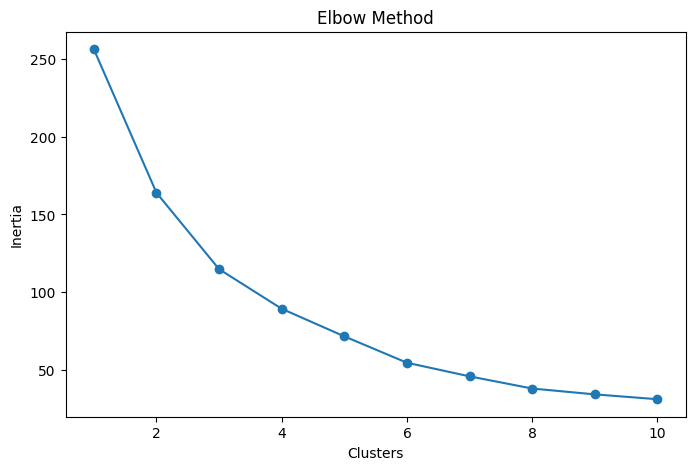

In [46]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker='o'
)

plt.title("Elbow Method")

plt.xlabel("Clusters")

plt.ylabel("Inertia")

plt.show()

In [47]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(
    X_scaled
)

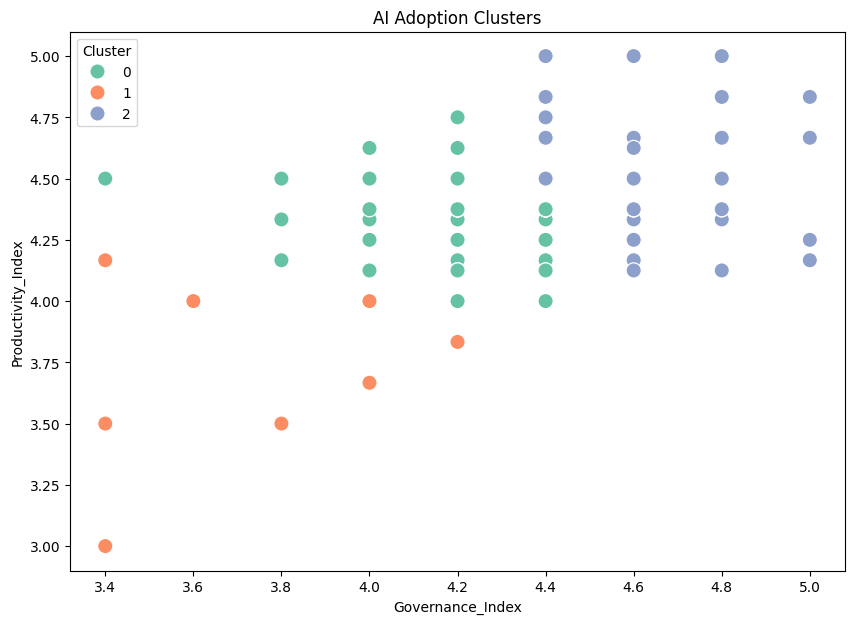

In [48]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df,
    x="Governance_Index",
    y="Productivity_Index",
    hue="Cluster",
    palette="Set2",
    s=120
)

plt.title(
    "AI Adoption Clusters"
)

plt.show()

In [49]:
cluster_summary = (
    df.groupby("Cluster")
    [
        [
            "Productivity_Index",
            "Governance_Index"
        ]
    ]
    .mean()
)

print(cluster_summary)

         Productivity_Index  Governance_Index
Cluster                                      
0                  4.323171          4.200000
1                  3.716667          3.800000
2                  4.494213          4.672222


In [50]:
frequency_map = {

"Rarely":1,
"Monthly":2,
"Weekly":3,
"Daily":4,
"Multiple Times Daily":5

}

freq_col = "How frequently do you use Generative AI in your work?"

df["Frequency_Score"] = (
    df[freq_col]
    .map(frequency_map)
)

In [51]:
time_map = {

"Less than 1 Hour":1,
"1-3 Hours":2,
"4-6 Hours":3,
"7-10 Hours":4,
"More than 10 Hours":5

}

time_col = "Estimated Time Saved Per Week Using AI"

df["TimeSaved_Score"] = (
    df[time_col]
    .map(time_map)
)

In [52]:
import statsmodels.api as sm

X = df[
    [
        "Frequency_Score",
        "TimeSaved_Score"
    ]
]

y = df["Productivity_Index"]

X = sm.add_constant(X)

model = sm.OLS(
    y,
    X
).fit()

print(model.summary())

MissingDataError: exog contains inf or nans

In [53]:
print(df["Frequency_Score"].isna().sum())
print(df["TimeSaved_Score"].isna().sum())

0
128


In [54]:
print(df["How frequently do you use Generative AI in your work?"].unique())

print(df["Estimated Time Saved Per Week Using AI"].unique())

['Multiple Times Daily' 'Daily' 'Weekly']
['1–3 Hours' '7–10 Hours' '4–6 Hours' '5' '4' '3']


In [55]:
freq_col = "How frequently do you use Generative AI in your work?"
time_col = "Estimated Time Saved Per Week Using AI"

df[freq_col] = (
    df[freq_col]
    .astype(str)
    .str.strip()
)

df[time_col] = (
    df[time_col]
    .astype(str)
    .str.strip()
)

In [56]:
print(df[freq_col].value_counts())

print(df[time_col].value_counts())

How frequently do you use Generative AI in your work?
Weekly                  52
Daily                   39
Multiple Times Daily    37
Name: count, dtype: int64
Estimated Time Saved Per Week Using AI
4             83
5             37
3              5
1–3 Hours      1
7–10 Hours     1
4–6 Hours      1
Name: count, dtype: int64


In [57]:
frequency_map = {
    "Rarely":1,
    "Monthly":2,
    "Weekly":3,
    "Daily":4,
    "Multiple Times Daily":5
}

df["Frequency_Score"] = (
    df[freq_col]
    .map(frequency_map)
)

In [58]:
print(
    df[
        df["Frequency_Score"].isna()
    ][freq_col]
)

print(
    df[
        df["TimeSaved_Score"].isna()
    ][time_col]
)

Series([], Name: How frequently do you use Generative AI in your work?, dtype: object)
0       1–3 Hours
1      7–10 Hours
2       4–6 Hours
3               5
4               5
          ...    
123             4
124             4
125             5
126             4
127             4
Name: Estimated Time Saved Per Week Using AI, Length: 128, dtype: object


In [59]:
print(df[freq_col].value_counts())
print(df[time_col].value_counts())

How frequently do you use Generative AI in your work?
Weekly                  52
Daily                   39
Multiple Times Daily    37
Name: count, dtype: int64
Estimated Time Saved Per Week Using AI
4             83
5             37
3              5
1–3 Hours      1
7–10 Hours     1
4–6 Hours      1
Name: count, dtype: int64


In [60]:
import statsmodels.api as sm

X = df[
    [
        "Frequency_Score",
        "TimeSaved_Score"
    ]
]

y = df["Productivity_Index"]

X = sm.add_constant(X)

model = sm.OLS(
    y,
    X
).fit()

print(model.summary())

MissingDataError: exog contains inf or nans

In [61]:
print(
    "Avg Productivity Index:",
    round(
        df["Productivity_Index"].mean(),
        2
    )
)

print(
    "Avg Governance Index:",
    round(
        df["Governance_Index"].mean(),
        2
    )
)

print(
    "Total Respondents:",
    len(df)
)

Avg Productivity Index: 4.32
Avg Governance Index: 4.3
Total Respondents: 128


In [62]:
import statsmodels.api as sm

X = df[[
    "Frequency_Score",
    "TimeSaved_Score"
]]

y = df["Productivity_Index"]

X = sm.add_constant(X)

model = sm.OLS(
    y,
    X
).fit()

print(model.summary())

MissingDataError: exog contains inf or nans

In [63]:
print("Frequency NaN:", df["Frequency_Score"].isna().sum())
print("TimeSaved NaN:", df["TimeSaved_Score"].isna().sum())

print("\nProblematic Frequency Values:")
print(
    df[df["Frequency_Score"].isna()][
        "How frequently do you use Generative AI in your work?"
    ].unique()
)

print("\nProblematic Time Saved Values:")
print(
    df[df["TimeSaved_Score"].isna()][
        "Estimated Time Saved Per Week Using AI"
    ].unique()
)


Frequency NaN: 0
TimeSaved NaN: 128

Problematic Frequency Values:
[]

Problematic Time Saved Values:
['1–3 Hours' '7–10 Hours' '4–6 Hours' '5' '4' '3']


In [64]:
X = df[
    [
        "Frequency_Score",
        "TimeSaved_Score"
    ]
].copy()

y = df["Productivity_Index"].copy()

analysis_df = pd.concat([X, y], axis=1)

analysis_df = analysis_df.dropna()

X = analysis_df[
    [
        "Frequency_Score",
        "TimeSaved_Score"
    ]
]

y = analysis_df["Productivity_Index"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

ValueError: zero-size array to reduction operation maximum which has no identity

In [65]:
analysis_df.shape

(0, 3)

In [66]:
print(df["Frequency_Score"].head(20))
print(df["TimeSaved_Score"].head(20))
print(df["Productivity_Index"].head(20))

0     5
1     5
2     5
3     4
4     3
5     3
6     3
7     4
8     4
9     3
10    4
11    4
12    4
13    3
14    3
15    3
16    3
17    3
18    3
19    3
Name: Frequency_Score, dtype: int64
0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
5    NaN
6    NaN
7    NaN
8    NaN
9    NaN
10   NaN
11   NaN
12   NaN
13   NaN
14   NaN
15   NaN
16   NaN
17   NaN
18   NaN
19   NaN
Name: TimeSaved_Score, dtype: float64
0     3.500000
1     3.000000
2     3.500000
3     4.166667
4     4.333333
5     4.166667
6     4.333333
7     4.166667
8     4.333333
9     4.333333
10    4.333333
11    4.333333
12    4.166667
13    4.333333
14    4.500000
15    4.333333
16    4.333333
17    4.333333
18    4.500000
19    4.500000
Name: Productivity_Index, dtype: float64


In [67]:
print(df["Frequency_Score"].isna().sum())
print(df["TimeSaved_Score"].isna().sum())
print(df["Productivity_Index"].isna().sum())

0
128
0


In [68]:
{
"1-3 Hours":2,
"4-6 Hours":3
}

{'1-3 Hours': 2, '4-6 Hours': 3}

In [69]:
freq_col = "How frequently do you use Generative AI in your work?"
time_col = "Estimated Time Saved Per Week Using AI"

print(df[freq_col].unique())

print("--------------------------------")

print(df[time_col].unique())

['Multiple Times Daily' 'Daily' 'Weekly']
--------------------------------
['1–3 Hours' '7–10 Hours' '4–6 Hours' '5' '4' '3']


In [70]:
print(df["Productivity_Index"].describe())

count    128.000000
mean       4.323893
std        0.280666
min        3.000000
25%        4.166667
50%        4.333333
75%        4.500000
max        5.000000
Name: Productivity_Index, dtype: float64


In [71]:
print(df[freq_col].unique())

print(df[time_col].unique())

print(df["Productivity_Index"].describe())

['Multiple Times Daily' 'Daily' 'Weekly']
['1–3 Hours' '7–10 Hours' '4–6 Hours' '5' '4' '3']
count    128.000000
mean       4.323893
std        0.280666
min        3.000000
25%        4.166667
50%        4.333333
75%        4.500000
max        5.000000
Name: Productivity_Index, dtype: float64


In [72]:
time_col = "Estimated Time Saved Per Week Using AI"

print(df[time_col].value_counts())

Estimated Time Saved Per Week Using AI
4             83
5             37
3              5
1–3 Hours      1
7–10 Hours     1
4–6 Hours      1
Name: count, dtype: int64


In [73]:
time_map = {
    "1–3 Hours": 2,
    "4–6 Hours": 3,
    "7–10 Hours": 4,
    "3": 2,
    "4": 3,
    "5": 4
}

df["TimeSaved_Score"] = (
    df[time_col]
    .astype(str)
    .str.strip()
    .map(time_map)
)

In [74]:
frequency_map = {
    "Weekly": 3,
    "Daily": 4,
    "Multiple Times Daily": 5
}

freq_col = "How frequently do you use Generative AI in your work?"

df["Frequency_Score"] = (
    df[freq_col]
    .astype(str)
    .str.strip()
    .map(frequency_map)
)

In [75]:
print(df["Frequency_Score"].isna().sum())
print(df["TimeSaved_Score"].isna().sum())
print(df["Productivity_Index"].isna().sum())

0
0
0


In [76]:
import statsmodels.api as sm

X = df[[
    "Frequency_Score",
    "TimeSaved_Score"
]]

y = df["Productivity_Index"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     Productivity_Index   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     1.677
Date:                Mon, 01 Jun 2026   Prob (F-statistic):              0.191
Time:                        18:03:09   Log-Likelihood:                -16.792
No. Observations:                 128   AIC:                             39.58
Df Residuals:                     125   BIC:                             48.14
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               3.9882      0.185     

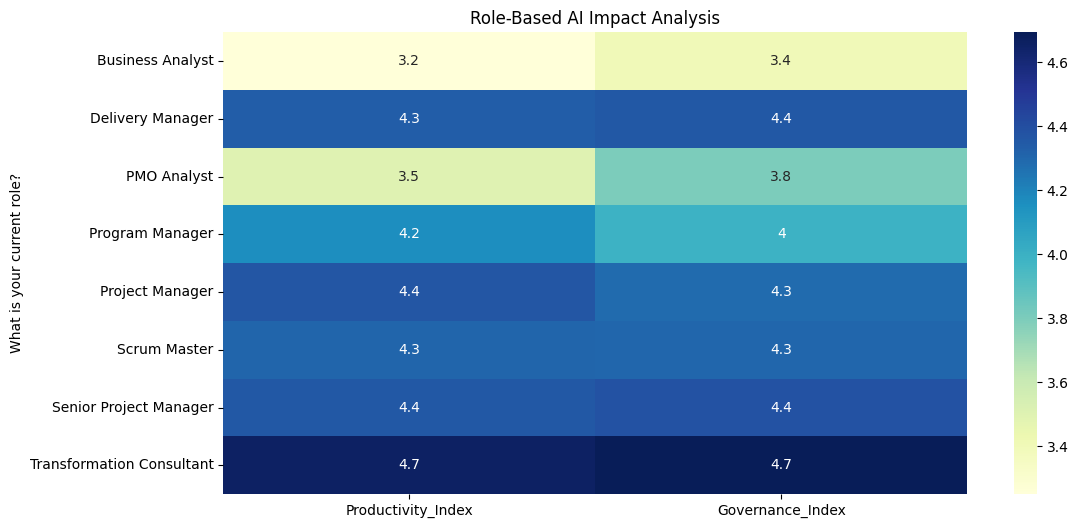

In [77]:
role_col = "What is your current role?"

role_matrix = (
    df.groupby(role_col)
    [["Productivity_Index","Governance_Index"]]
    .mean()
)

plt.figure(figsize=(12,6))

sns.heatmap(
    role_matrix,
    annot=True,
    cmap="YlGnBu"
)

plt.title("Role-Based AI Impact Analysis")

plt.show()

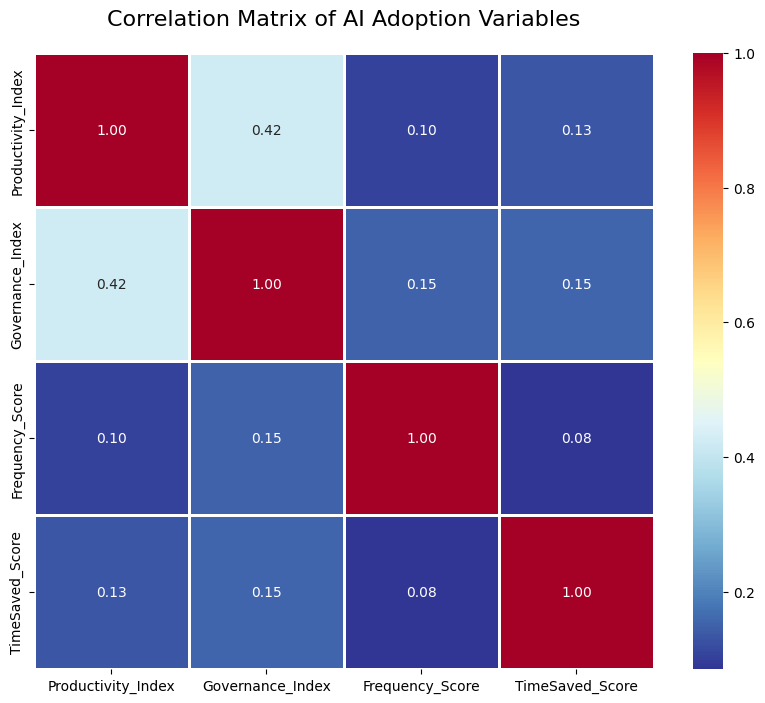

In [78]:
analysis_cols = [
    "Productivity_Index",
    "Governance_Index",
    "Frequency_Score",
    "TimeSaved_Score"
]

corr_matrix = df[analysis_cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="RdYlBu_r",
    fmt=".2f",
    linewidths=1
)

plt.title(
    "Correlation Matrix of AI Adoption Variables",
    fontsize=16,
    pad=20
)

plt.show()

In [79]:
import plotly.express as px

tool_col = "Which Generative AI tool do you use most frequently?"

tool_counts = (
    df[tool_col]
    .value_counts()
    .reset_index()
)

tool_counts.columns = ["Tool","Count"]

fig = px.treemap(
    tool_counts,
    path=["Tool"],
    values="Count",
    title="Generative AI Tool Adoption Landscape"
)

fig.show()

In [80]:
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

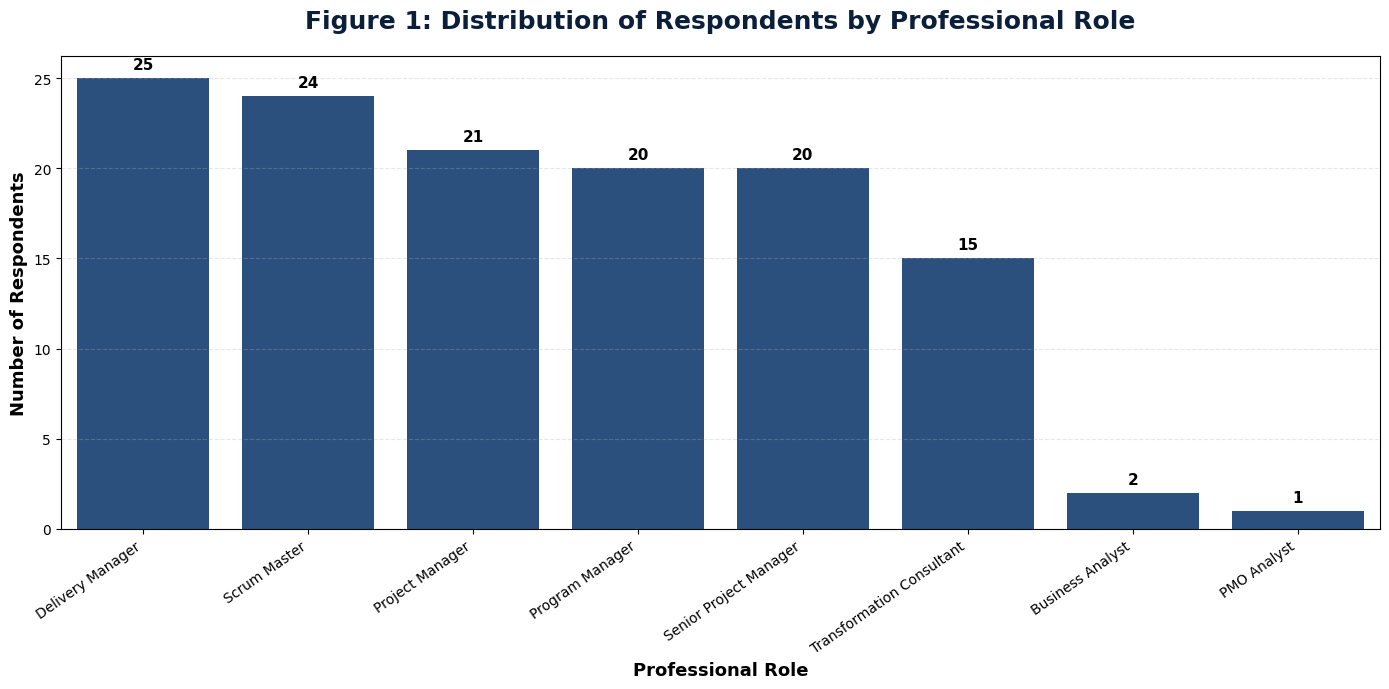

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

role_col = "What is your current role?"

role_counts = (
    df[role_col]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14,7))

ax = sns.barplot(
    x=role_counts.index,
    y=role_counts.values,
    color="#1E4E8C"
)

for i, value in enumerate(role_counts.values):
    ax.text(
        i,
        value + 0.5,
        str(value),
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title(
    "Figure 1: Distribution of Respondents by Professional Role",
    fontsize=18,
    fontweight='bold',
    color="#0B1F3A",
    pad=20
)

plt.xlabel(
    "Professional Role",
    fontsize=13,
    fontweight='bold'
)

plt.ylabel(
    "Number of Respondents",
    fontsize=13,
    fontweight='bold'
)

plt.xticks(
    rotation=35,
    ha='right'
)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()

plt.show()

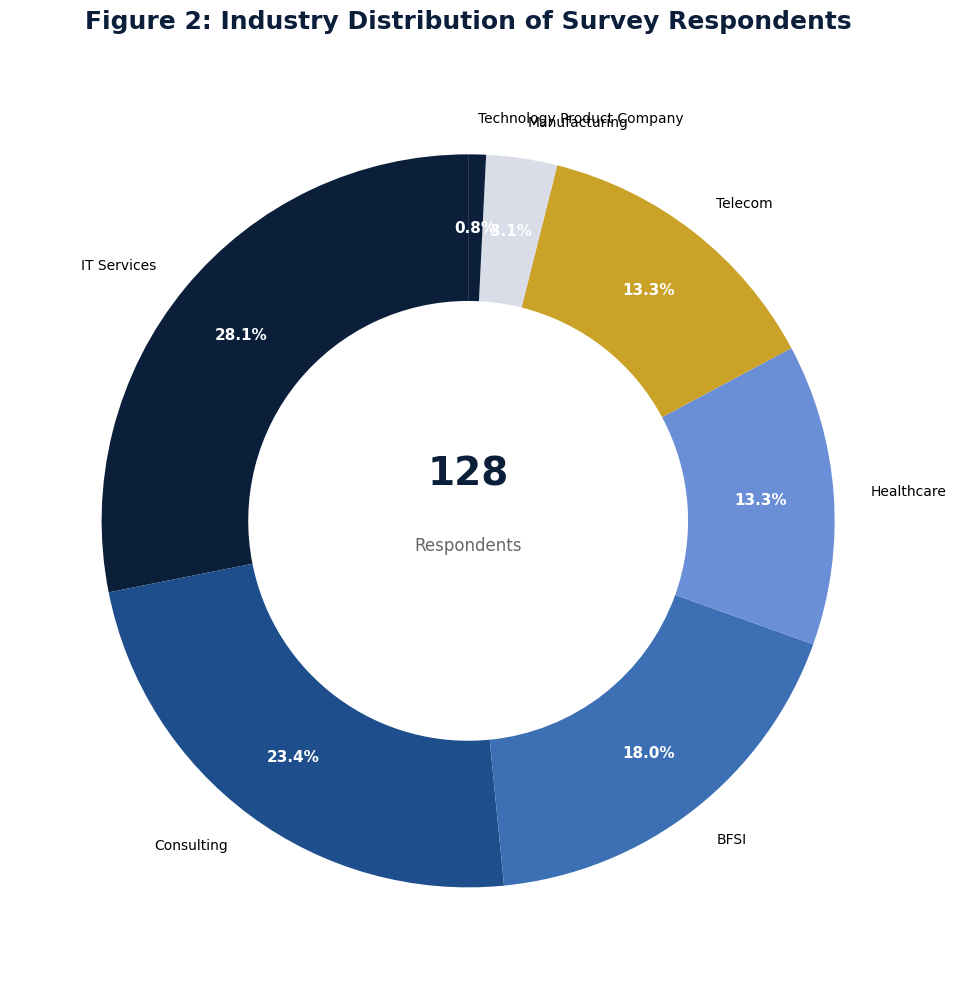

In [82]:
import matplotlib.pyplot as plt
import numpy as np

industry_col = "Which industry does your organization belong to?"

industry_counts = (
    df[industry_col]
    .value_counts()
)

# Royal Executive Palette
colors = [
    "#0B1F3A",  # Navy
    "#1E4E8C",  # Royal Blue
    "#3D6FB4",  # Medium Blue
    "#6B8FD6",  # Light Royal
    "#C9A227",  # Gold Accent
    "#D9DDE8"   # Soft Grey
]

fig, ax = plt.subplots(
    figsize=(10,10)
)

wedges, texts, autotexts = ax.pie(
    industry_counts,
    labels=industry_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.40),
    pctdistance=0.80
)

# Center Circle Text
total = industry_counts.sum()

ax.text(
    0,
    0.10,
    f"{total}",
    ha='center',
    fontsize=28,
    fontweight='bold',
    color="#0B1F3A"
)

ax.text(
    0,
    -0.08,
    "Respondents",
    ha='center',
    fontsize=12,
    color="#666666"
)

# Styling Labels
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontsize(11)
    autotext.set_fontweight("bold")

plt.title(
    "Figure 2: Industry Distribution of Survey Respondents",
    fontsize=18,
    fontweight='bold',
    color="#0B1F3A",
    pad=25
)

plt.tight_layout()

plt.show()

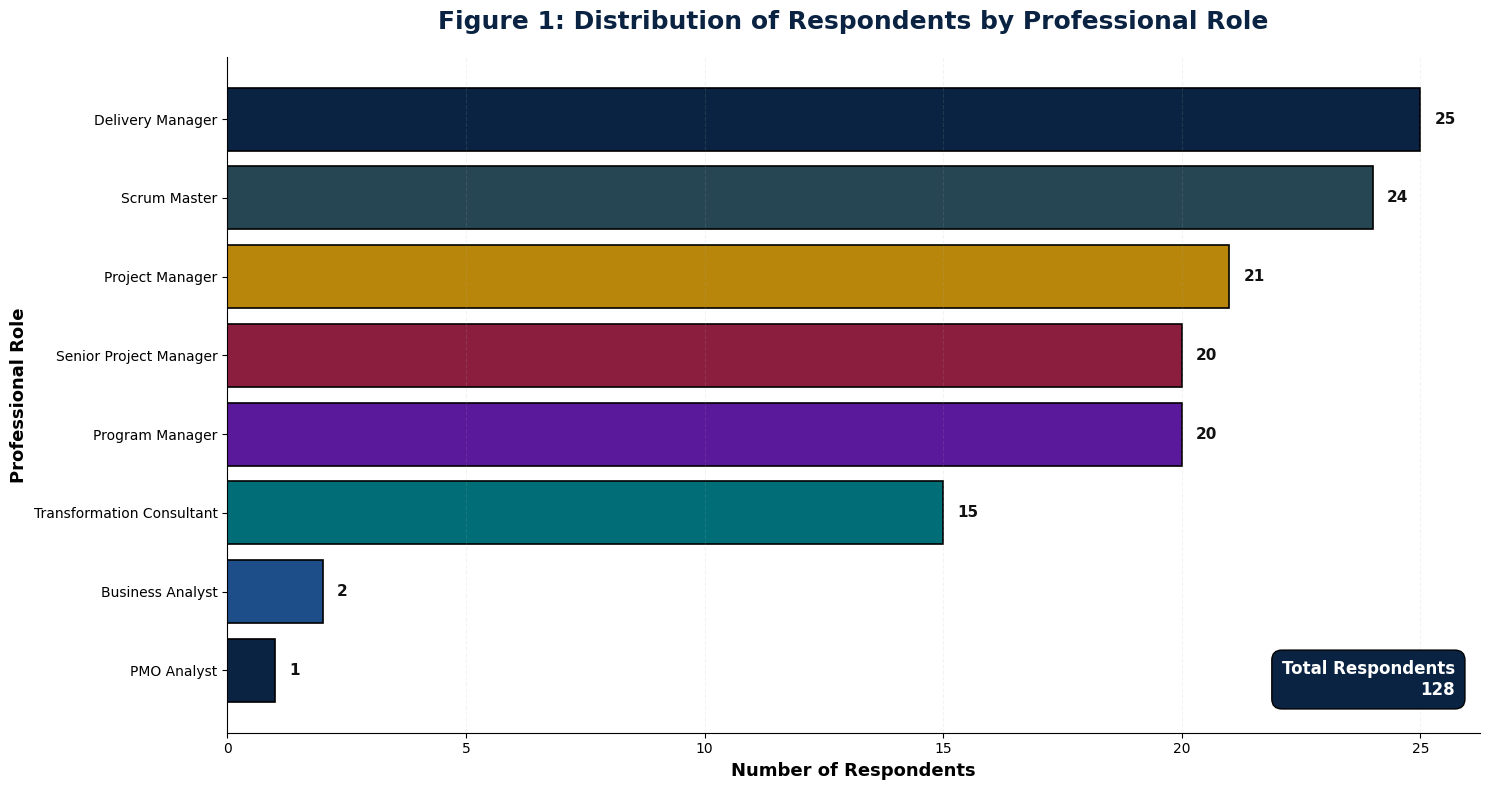

In [84]:
# ==========================================
# FIGURE 1
# DISTRIBUTION OF RESPONDENTS BY ROLE
# Premium Executive Version
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# Theme Configuration
# -------------------------------

plt.rcParams['font.family'] = 'DejaVu Sans'

PRIMARY_NAVY = "#0A2342"
ROYAL_BLUE = "#1D4E89"
TEAL = "#006D77"
PURPLE = "#5A189A"
BURGUNDY = "#8B1E3F"
GOLD = "#B8860B"
SLATE = "#264653"

# Executive Palette
colors = [
    PRIMARY_NAVY,
    ROYAL_BLUE,
    TEAL,
    PURPLE,
    BURGUNDY,
    GOLD,
    SLATE
]

# -------------------------------
# Data Preparation
# -------------------------------

role_col = "What is your current role?"

role_counts = (
    df[role_col]
    .value_counts()
    .sort_values(ascending=True)
)

# Extend palette if required
plot_colors = (colors * 5)[:len(role_counts)]

# -------------------------------
# Figure Creation
# -------------------------------

fig, ax = plt.subplots(
    figsize=(15,8)
)

bars = ax.barh(
    role_counts.index,
    role_counts.values,
    color=plot_colors,
    edgecolor="black",
    linewidth=1.2
)

# -------------------------------
# Data Labels
# -------------------------------

for bar in bars:

    width = bar.get_width()

    ax.text(
        width + 0.3,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va='center',
        fontsize=11,
        fontweight='bold',
        color="#111111"
    )

# -------------------------------
# KPI Box
# -------------------------------

total = role_counts.sum()

ax.text(
    0.98,
    0.05,
    f"Total Respondents\n{total}",
    transform=ax.transAxes,
    ha='right',
    va='bottom',
    fontsize=12,
    fontweight='bold',
    color='white',
    bbox=dict(
        facecolor=PRIMARY_NAVY,
        edgecolor='black',
        boxstyle="round,pad=0.6"
    )
)

# -------------------------------
# Titles
# -------------------------------

plt.title(
    "Figure 1: Distribution of Respondents by Professional Role",
    fontsize=18,
    fontweight='bold',
    color=PRIMARY_NAVY,
    pad=20
)

plt.xlabel(
    "Number of Respondents",
    fontsize=13,
    fontweight='bold'
)

plt.ylabel(
    "Professional Role",
    fontsize=13,
    fontweight='bold'
)

# -------------------------------
# Grid Styling
# -------------------------------

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.15
)

sns.despine(
    top=True,
    right=True
)

# -------------------------------
# Layout
# -------------------------------

plt.tight_layout()

plt.show()

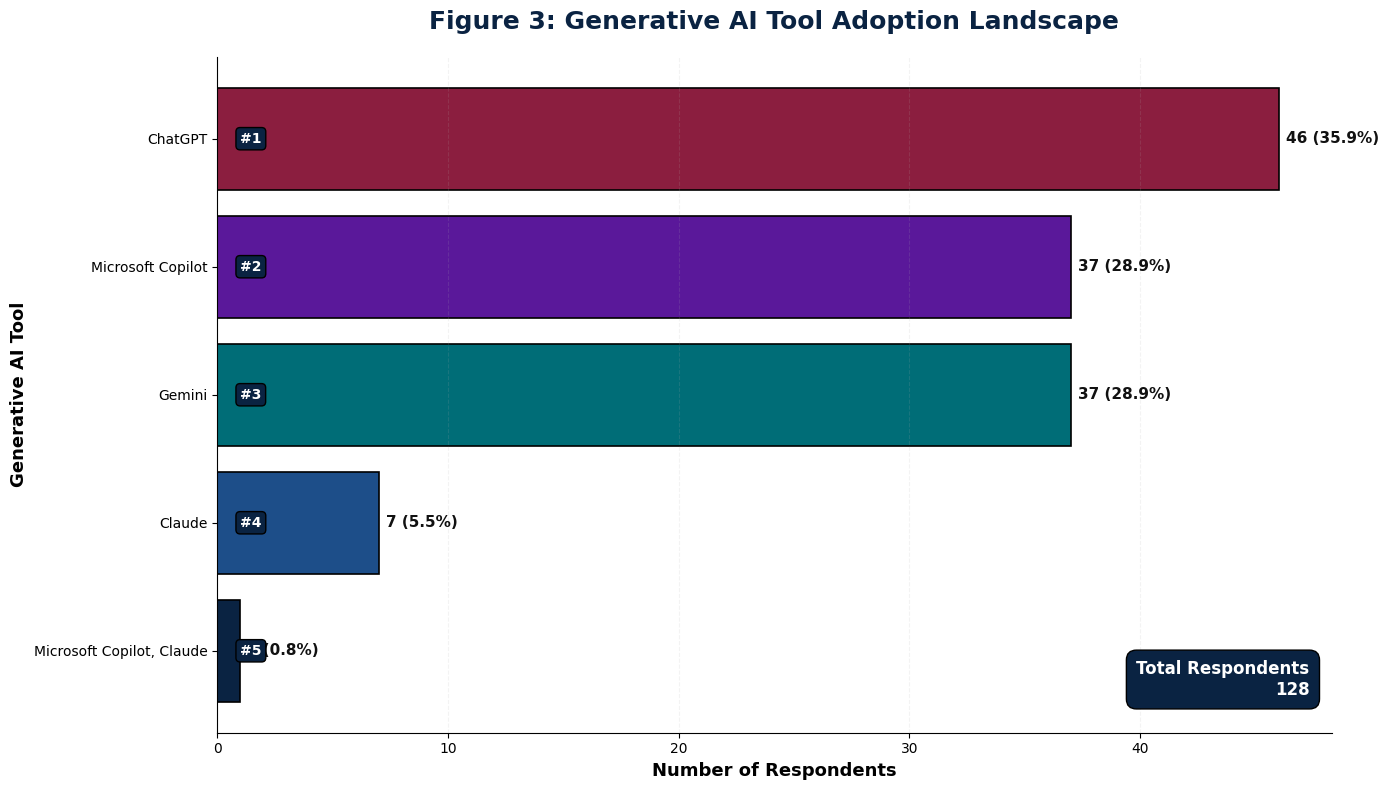

In [85]:
# ==========================================
# FIGURE 3
# GENERATIVE AI TOOL ADOPTION LANDSCAPE
# Premium Executive Version
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -------------------------------
# Theme
# -------------------------------

PRIMARY_NAVY = "#0A2342"
ROYAL_BLUE = "#1D4E89"
TEAL = "#006D77"
PURPLE = "#5A189A"
BURGUNDY = "#8B1E3F"
GOLD = "#B8860B"
SLATE = "#264653"

THEME = [
    PRIMARY_NAVY,
    ROYAL_BLUE,
    TEAL,
    PURPLE,
    BURGUNDY,
    GOLD,
    SLATE
]

# -------------------------------
# Data
# -------------------------------

tool_col = "Which Generative AI tool do you use most frequently?"

tool_counts = (
    df[tool_col]
    .value_counts()
    .sort_values(ascending=True)
)

total = tool_counts.sum()

# -------------------------------
# Figure
# -------------------------------

fig, ax = plt.subplots(
    figsize=(14,8)
)

colors = THEME[:len(tool_counts)]

bars = ax.barh(
    tool_counts.index,
    tool_counts.values,
    color=colors,
    edgecolor="black",
    linewidth=1.2
)

# -------------------------------
# Labels
# -------------------------------

for i, bar in enumerate(bars):

    count = bar.get_width()

    percentage = (
        count / total
    ) * 100

    ax.text(
        count + 0.3,
        bar.get_y() + bar.get_height()/2,
        f"{int(count)} ({percentage:.1f}%)",
        va='center',
        fontsize=11,
        fontweight='bold',
        color="#111111"
    )

# -------------------------------
# Ranking Badges
# -------------------------------

ranked_tools = (
    tool_counts.sort_values(
        ascending=False
    )
)

for rank, (tool, value) in enumerate(
    ranked_tools.items(),
    start=1
):

    idx = list(tool_counts.index).index(tool)

    ax.text(
        1,
        idx,
        f"#{rank}",
        va='center',
        fontsize=10,
        fontweight='bold',
        color='white',
        bbox=dict(
            facecolor=PRIMARY_NAVY,
            edgecolor='black',
            boxstyle='round,pad=0.3'
        )
    )

# -------------------------------
# KPI Card
# -------------------------------

ax.text(
    0.98,
    0.05,
    f"Total Respondents\n{total}",
    transform=ax.transAxes,
    ha='right',
    va='bottom',
    fontsize=12,
    fontweight='bold',
    color='white',
    bbox=dict(
        facecolor=PRIMARY_NAVY,
        edgecolor='black',
        boxstyle='round,pad=0.6'
    )
)

# -------------------------------
# Titles
# -------------------------------

plt.title(
    "Figure 3: Generative AI Tool Adoption Landscape",
    fontsize=18,
    fontweight='bold',
    color=PRIMARY_NAVY,
    pad=20
)

plt.xlabel(
    "Number of Respondents",
    fontsize=13,
    fontweight='bold'
)

plt.ylabel(
    "Generative AI Tool",
    fontsize=13,
    fontweight='bold'
)

# -------------------------------
# Grid
# -------------------------------

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.15
)

sns.despine(
    top=True,
    right=True
)

plt.tight_layout()

plt.show()

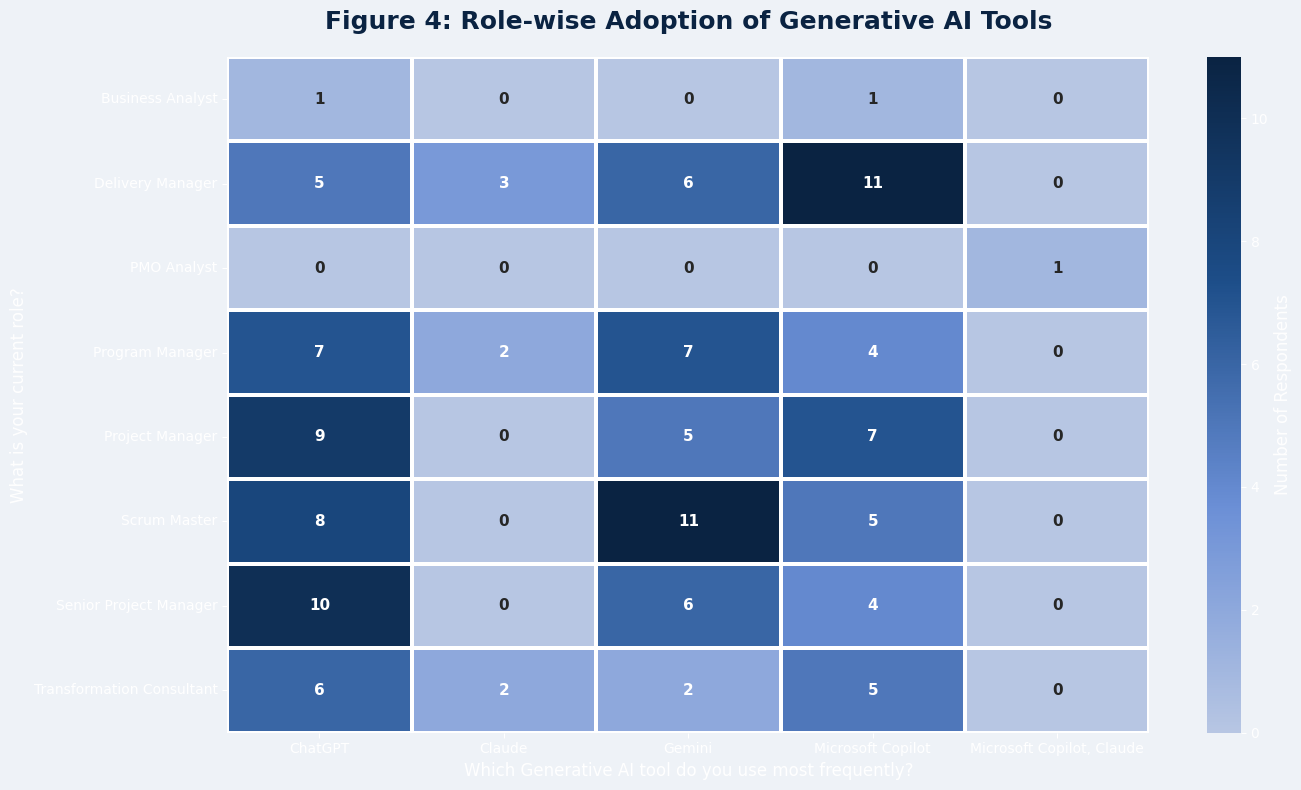

In [93]:
from matplotlib.colors import LinearSegmentedColormap

executive_cmap = LinearSegmentedColormap.from_list(
    "executive",
    [
        "#B7C6E3",
        "#6B8FD6",
        "#1D4E89",
        "#0A2342"
    ]
)

fig, ax = plt.subplots(
    figsize=(14,8),
    facecolor="#EEF2F7"
)

ax.set_facecolor("#EEF2F7")

sns.heatmap(
    role_tool_matrix,
    annot=True,
    fmt="d",
    cmap=executive_cmap,
    linewidths=1.5,
    linecolor="white",
    annot_kws={
        "fontsize":11,
        "fontweight":"bold"
    },
    cbar_kws={
        "label":"Number of Respondents"
    }
)

plt.title(
    "Figure 4: Role-wise Adoption of Generative AI Tools",
    fontsize=18,
    fontweight="bold",
    color="#0A2342",
    pad=20
)

plt.tight_layout()
plt.show()

NameError: name 'WHITE' is not defined

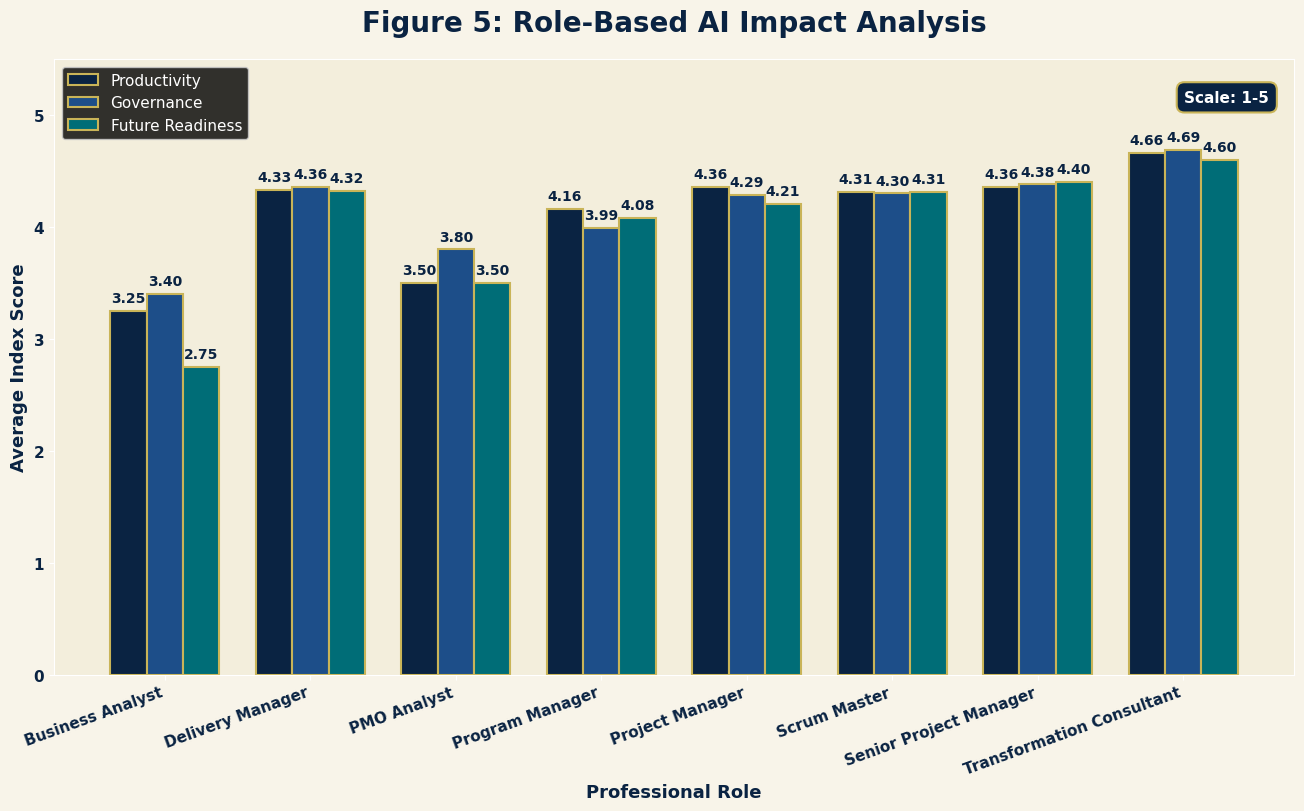

In [113]:
# ==========================================
# FIGURE 5
# ROLE-BASED AI IMPACT ANALYSIS
# Premium Executive Version
# Bone White Theme
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --------------------------------
# Theme
# --------------------------------

PRIMARY_NAVY = "#0A2342"
ROYAL_BLUE   = "#1D4E89"
TEAL         = "#006D77"

BONE_WHITE   = "#F8F4E9"
IVORY        = "#F3EEDC"
LIME_GOLD    = "#C9B458"

# --------------------------------
# Data
# --------------------------------

role_col = "What is your current role?"

role_impact_matrix = (
    df.groupby(role_col)
    [
        [
            "Productivity_Index",
            "Governance_Index",
            "Future_Readiness_Index"
        ]
    ]
    .mean()
    .round(2)
)

# --------------------------------
# Plot Setup
# --------------------------------

roles = role_impact_matrix.index

x = np.arange(len(roles))

width = 0.25

fig, ax = plt.subplots(
    figsize=(16,8),
    facecolor=BONE_WHITE
)

ax.set_facecolor(IVORY)

# --------------------------------
# Bars
# --------------------------------

bars1 = ax.bar(
    x - width,
    role_impact_matrix["Productivity_Index"],
    width,
    label="Productivity",
    color=PRIMARY_NAVY,
    edgecolor=LIME_GOLD,
    linewidth=1.5
)

bars2 = ax.bar(
    x,
    role_impact_matrix["Governance_Index"],
    width,
    label="Governance",
    color=ROYAL_BLUE,
    edgecolor=LIME_GOLD,
    linewidth=1.5
)

bars3 = ax.bar(
    x + width,
    role_impact_matrix["Future_Readiness_Index"],
    width,
    label="Future Readiness",
    color=TEAL,
    edgecolor=LIME_GOLD,
    linewidth=1.5
)

# --------------------------------
# Data Labels
# --------------------------------

for bars in [bars1, bars2, bars3]:

    for bar in bars:

        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.05,
            f"{height:.2f}",
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold',
            color=PRIMARY_NAVY
        )

# --------------------------------
# KPI Card
# --------------------------------

ax.text(
    0.98,
    0.95,
    "Scale: 1-5",
    transform=ax.transAxes,
    ha='right',
    va='top',
    fontsize=11,
    fontweight='bold',
    color='white',
    bbox=dict(
        facecolor=PRIMARY_NAVY,
        edgecolor=LIME_GOLD,
        linewidth=1.5,
        boxstyle='round,pad=0.5'
    )
)

# --------------------------------
# Titles
# --------------------------------

plt.title(
    "Figure 5: Role-Based AI Impact Analysis",
    fontsize=20,
    fontweight='bold',
    color=PRIMARY_NAVY,
    pad=20
)

plt.xlabel(
    "Professional Role",
    fontsize=13,
    fontweight='bold',
    color=PRIMARY_NAVY
)

plt.ylabel(
    "Average Index Score",
    fontsize=13,
    fontweight='bold',
    color=PRIMARY_NAVY
)

# --------------------------------
# X & Y Axis Formatting
# --------------------------------

plt.xticks(
    x,
    roles,
    rotation=20,
    ha='right',
    fontsize=11,
    fontweight='bold',
    color=PRIMARY_NAVY
)

plt.yticks(
    fontsize=11,
    fontweight='bold',
    color=PRIMARY_NAVY
)

plt.ylim(0, 5.5)

# --------------------------------
# Legend
# --------------------------------

legend = plt.legend(
    loc="upper left",
    frameon=True,
    fontsize=11

)

legend.get_frame().set_facecolor(WHITE)
legend.get_frame().set_edgecolor(LIME_GOLD)
legend.get_frame().set_linewidth(1.2)

# --------------------------------
# Grid
# --------------------------------

plt.grid(
    axis='y',
    linestyle='--',
    color=LIME_GOLD,
    alpha=0.25
)

# --------------------------------
# Plot Border
# --------------------------------

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color(LIME_GOLD)
    spine.set_linewidth(1.2)

# --------------------------------
# Footer
# --------------------------------

plt.figtext(
    0.5,
    0.01,
    "Source: Primary Survey Data (n = 128)",
    ha='center',
    fontsize=10,
    style='italic',
    color="#555555"
)

sns.despine(
    top=False,
    right=False
)

plt.tight_layout()

plt.show()

In [103]:
future_cols = [

"Generative AI will become an essential component of project management.",

"AI adoption will improve project success rates."

]

df["Future_Readiness_Index"] = (
    df[future_cols]
    .mean(axis=1)
)

In [115]:
analysis_cols = [
    "Productivity_Index",
    "Governance_Index",
    "Frequency_Score",
    "TimeSaved_Score",
    "Future_Readiness_Index"
]

corr_matrix = df[analysis_cols].corr()

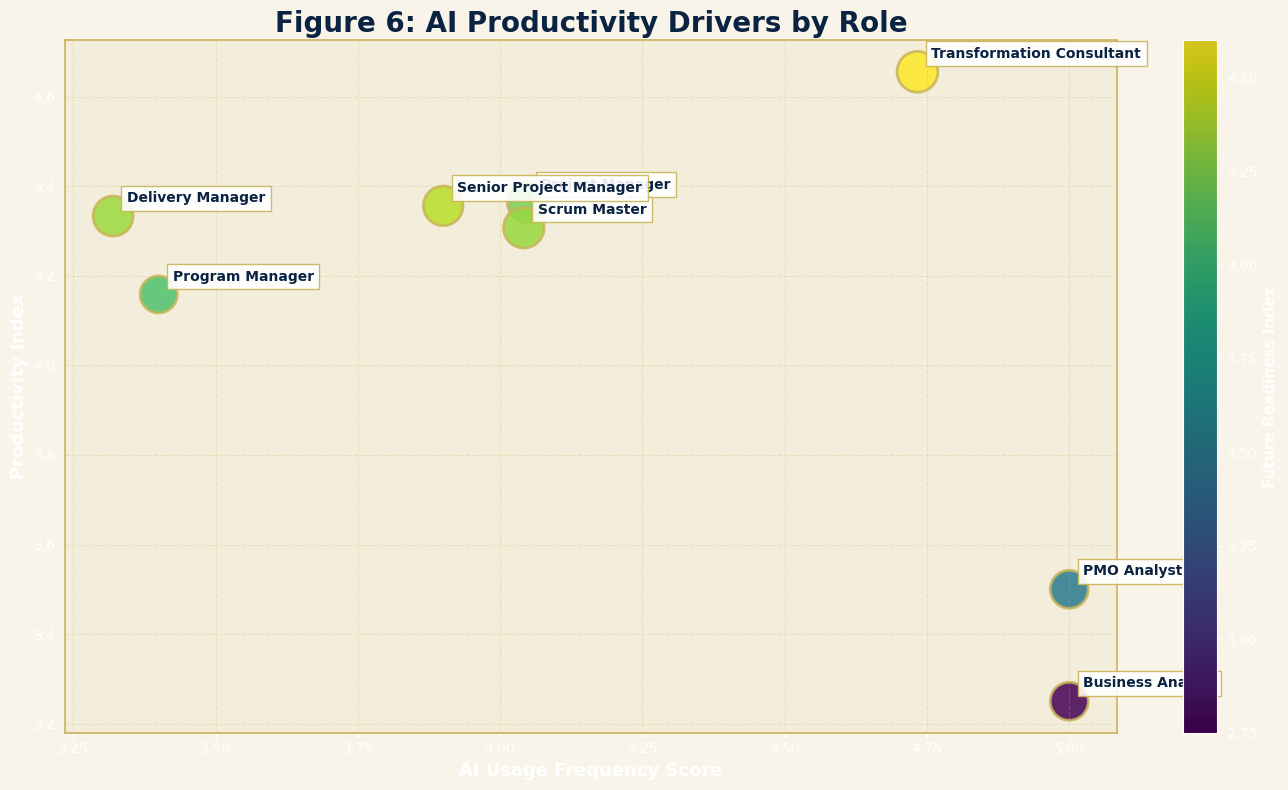

In [118]:
# ==========================================
# FIGURE 6
# AI PRODUCTIVITY DRIVERS BY ROLE
# Executive Bubble Chart
# ==========================================

import matplotlib.pyplot as plt

PRIMARY_NAVY = "#0A2342"
BONE_WHITE = "#F8F4E9"
IVORY = "#F3EEDC"
LIME_GOLD = "#C9B458"

# --------------------------------
# Aggregate by Role
# --------------------------------

role_summary = (
    df.groupby("What is your current role?")
    .agg({
        "Frequency_Score":"mean",
        "Productivity_Index":"mean",
        "TimeSaved_Score":"mean",
        "Future_Readiness_Index":"mean"
    })
    .reset_index()
)

# --------------------------------
# Figure
# --------------------------------

fig, ax = plt.subplots(
    figsize=(14,8),
    facecolor=BONE_WHITE
)

ax.set_facecolor(IVORY)

scatter = ax.scatter(
    role_summary["Frequency_Score"],
    role_summary["Productivity_Index"],
    s=role_summary["TimeSaved_Score"] * 250,
    c=role_summary["Future_Readiness_Index"],
    cmap="viridis",
    edgecolors=LIME_GOLD,
    linewidths=2,
    alpha=0.85
)

# --------------------------------
# Role Labels
# --------------------------------

for _, row in role_summary.iterrows():

    ax.annotate(
        row["What is your current role?"],
        (
            row["Frequency_Score"],
            row["Productivity_Index"]
        ),
        xytext=(10,10),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
        color=PRIMARY_NAVY,
        bbox=dict(
            facecolor="white",
            edgecolor=LIME_GOLD,
            alpha=0.9
        )
    )

# --------------------------------
# Color Bar
# --------------------------------

cbar = plt.colorbar(scatter)

cbar.set_label(
    "Future Readiness Index",
    fontsize=11,
    fontweight="bold"
)

# --------------------------------
# Titles
# --------------------------------

plt.title(
    "Figure 6: AI Productivity Drivers by Role",
    fontsize=20,
    fontweight="bold",
    color=PRIMARY_NAVY
)

plt.xlabel(
    "AI Usage Frequency Score",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Productivity Index",
    fontsize=13,
    fontweight="bold"
)

# --------------------------------
# Grid
# --------------------------------

plt.grid(
    linestyle="--",
    alpha=0.25,
    color=LIME_GOLD
)

# --------------------------------
# Border
# --------------------------------

for spine in ax.spines.values():
    spine.set_color(LIME_GOLD)
    spine.set_linewidth(1.2)

plt.tight_layout()
plt.show()

NameError: name 'WHITE' is not defined

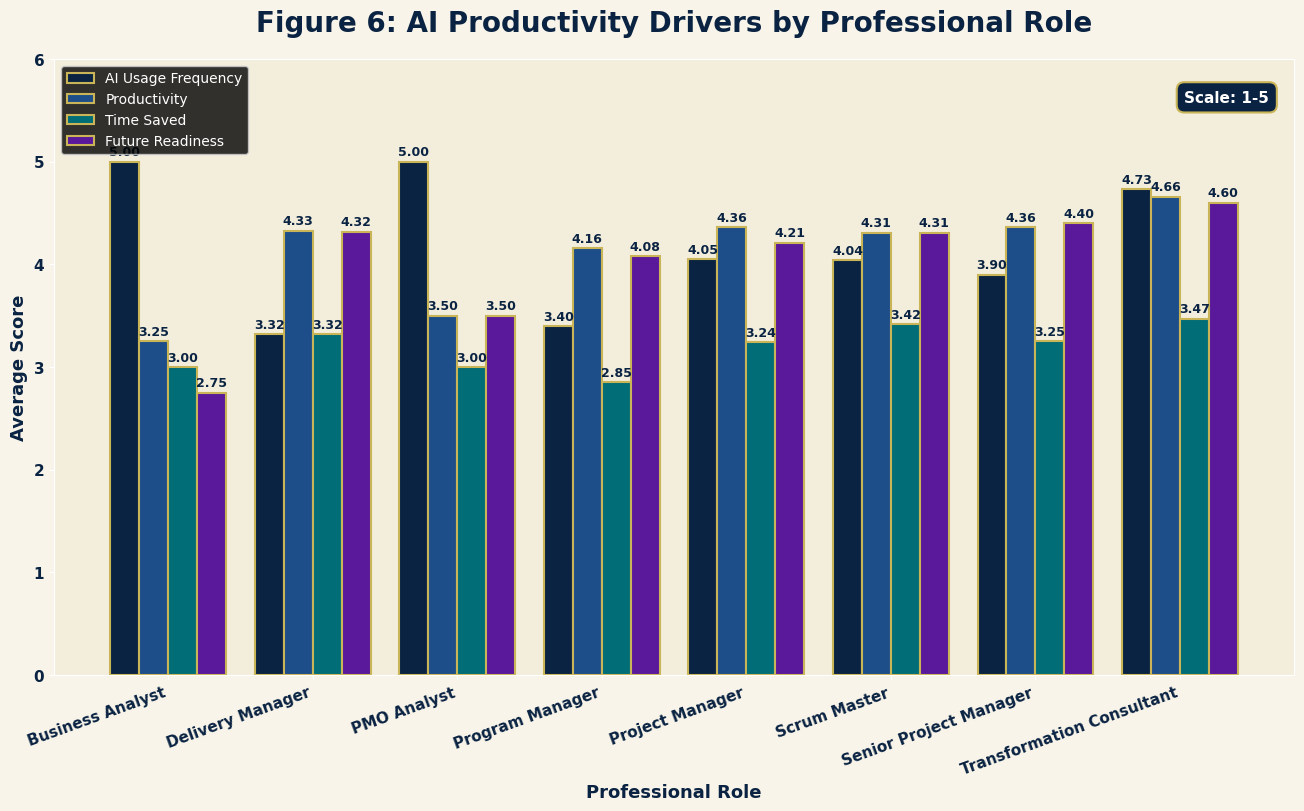

In [125]:
# ==========================================
# FIGURE 6
# AI PRODUCTIVITY DRIVERS BY ROLE
# Premium Clustered Bar Chart
# ==========================================

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# --------------------------------
# Theme
# --------------------------------

PRIMARY_NAVY = "#0A2342"
ROYAL_BLUE   = "#1D4E89"
TEAL         = "#006D77"
PURPLE       = "#5A189A"

BONE_WHITE   = "#F8F4E9"
IVORY        = "#F3EEDC"
LIME_GOLD    = "#C9B458"

# --------------------------------
# Role Summary
# --------------------------------

role_summary = (
    df.groupby("What is your current role?")
    .agg({
        "Frequency_Score":"mean",
        "Productivity_Index":"mean",
        "TimeSaved_Score":"mean",
        "Future_Readiness_Index":"mean"
    })
    .round(2)
)

# --------------------------------
# Plot Setup
# --------------------------------

roles = role_summary.index

x = np.arange(len(roles))
width = 0.20

fig, ax = plt.subplots(
    figsize=(16,8),
    facecolor=BONE_WHITE
)

ax.set_facecolor(IVORY)

# --------------------------------
# Bars
# --------------------------------

bars1 = ax.bar(
    x - 1.5*width,
    role_summary["Frequency_Score"],
    width,
    label="AI Usage Frequency",
    color=PRIMARY_NAVY,
    edgecolor=LIME_GOLD,
    linewidth=1.5
)

bars2 = ax.bar(
    x - 0.5*width,
    role_summary["Productivity_Index"],
    width,
    label="Productivity",
    color=ROYAL_BLUE,
    edgecolor=LIME_GOLD,
    linewidth=1.5
)

bars3 = ax.bar(
    x + 0.5*width,
    role_summary["TimeSaved_Score"],
    width,
    label="Time Saved",
    color=TEAL,
    edgecolor=LIME_GOLD,
    linewidth=1.5
)

bars4 = ax.bar(
    x + 1.5*width,
    role_summary["Future_Readiness_Index"],
    width,
    label="Future Readiness",
    color=PURPLE,
    edgecolor=LIME_GOLD,
    linewidth=1.5
)

# --------------------------------
# Data Labels
# --------------------------------

for bar_group in [bars1, bars2, bars3, bars4]:

    for bar in bar_group:

        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.03,
            f"{height:.2f}",
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold',
            color=PRIMARY_NAVY
        )

# --------------------------------
# KPI Card
# --------------------------------

ax.text(
    0.98,
    0.95,
    "Scale: 1-5",
    transform=ax.transAxes,
    ha='right',
    va='top',
    fontsize=11,
    fontweight='bold',
    color='white',
    bbox=dict(
        facecolor=PRIMARY_NAVY,
        edgecolor=LIME_GOLD,
        linewidth=1.5,
        boxstyle='round,pad=0.5'
    )
)

# --------------------------------
# Title
# --------------------------------

plt.title(
    "Figure 6: AI Productivity Drivers by Professional Role",
    fontsize=20,
    fontweight='bold',
    color=PRIMARY_NAVY,
    pad=20
)

# --------------------------------
# Axis Labels
# --------------------------------

plt.xlabel(
    "Professional Role",
    fontsize=13,
    fontweight='bold',
    color=PRIMARY_NAVY
)

plt.ylabel(
    "Average Score",
    fontsize=13,
    fontweight='bold',
    color=PRIMARY_NAVY
)

# --------------------------------
# X Axis
# --------------------------------

plt.xticks(
    x,
    roles,
    rotation=20,
    ha='right',
    fontsize=11,
    fontweight='bold',
    color=PRIMARY_NAVY
)

plt.yticks(
    fontsize=11,
    fontweight='bold',
    color=PRIMARY_NAVY
)

plt.ylim(0, 6)

# --------------------------------
# Legend
# --------------------------------

legend = plt.legend(
    loc='upper left',
    frameon=True,
    fontsize=10
)

legend.get_frame().set_facecolor(WHITE),
legend.get_frame().set_edgecolor(LIME_GOLD)

# --------------------------------
# Grid
# --------------------------------

plt.grid(
    axis='y',
    linestyle='--',
    color=LIME_GOLD,
    alpha=0.25
)

# --------------------------------
# Border
# --------------------------------

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color(LIME_GOLD)
    spine.set_linewidth(1.2)

# --------------------------------
# Footer
# --------------------------------

plt.figtext(
    0.5,
    0.01,
    "Source: Primary Survey Data (n = 128)",
    ha='center',
    fontsize=10,
    style='italic',
    color="#555555"
)

sns.despine(
    top=False,
    right=False
)

plt.tight_layout()
plt.show()

In [126]:
activity_col = "Which project management activities do you use AI for? (Select all that apply) "

activity_counts = (
    df[activity_col]
    .str.split(";")
    .explode()
    .value_counts()
    .sort_values(ascending=True)
)

KeyError: 'Which project management activities do you use AI for? (Select all that apply) '

In [133]:
activity_col = 'Which project management activities do you use AI for? (Select all that apply)'

activity_counts = (
    df[activity_col]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
    .value_counts()
    .sort_values(ascending=True)
)

total = len(df)

activity_percent = (
    activity_counts / total * 100
).round(1)

In [130]:
activity_col = "Which project management activities do you use AI for? (Select all that apply) "


In [131]:
activity_col = [col for col in df.columns if "project management activities" in col.lower()][0]

print(activity_col)

Which project management activities do you use AI for? (Select all that apply)


In [132]:
list(df.columns)

['Timestamp',
 'What is your current role?',
 'How many years of professional experience do you have?',
 'Which function do you primarily work in?',
 'Which industry does your organization belong to?',
 'Which Generative AI tool do you use most frequently?',
 'How frequently do you use Generative AI in your work?',
 'Approximately what percentage of your work activities are supported by AI?',
 'Which project management activities do you use AI for? (Select all that apply)',
 'Generative AI reduces the effort required for project documentation.',
 'Generative AI improves the quality of project reports and presentations.',
 'Generative AI accelerates meeting summary and MOM preparation.',
 'Generative AI improves decision-making speed.',
 'Generative AI reduces repetitive administrative work.',
 'Generative AI increases overall productivity.',
 'Generative AI will significantly transform PMO and project delivery operations.',
 'Generative AI improves stakeholder communication effectivene

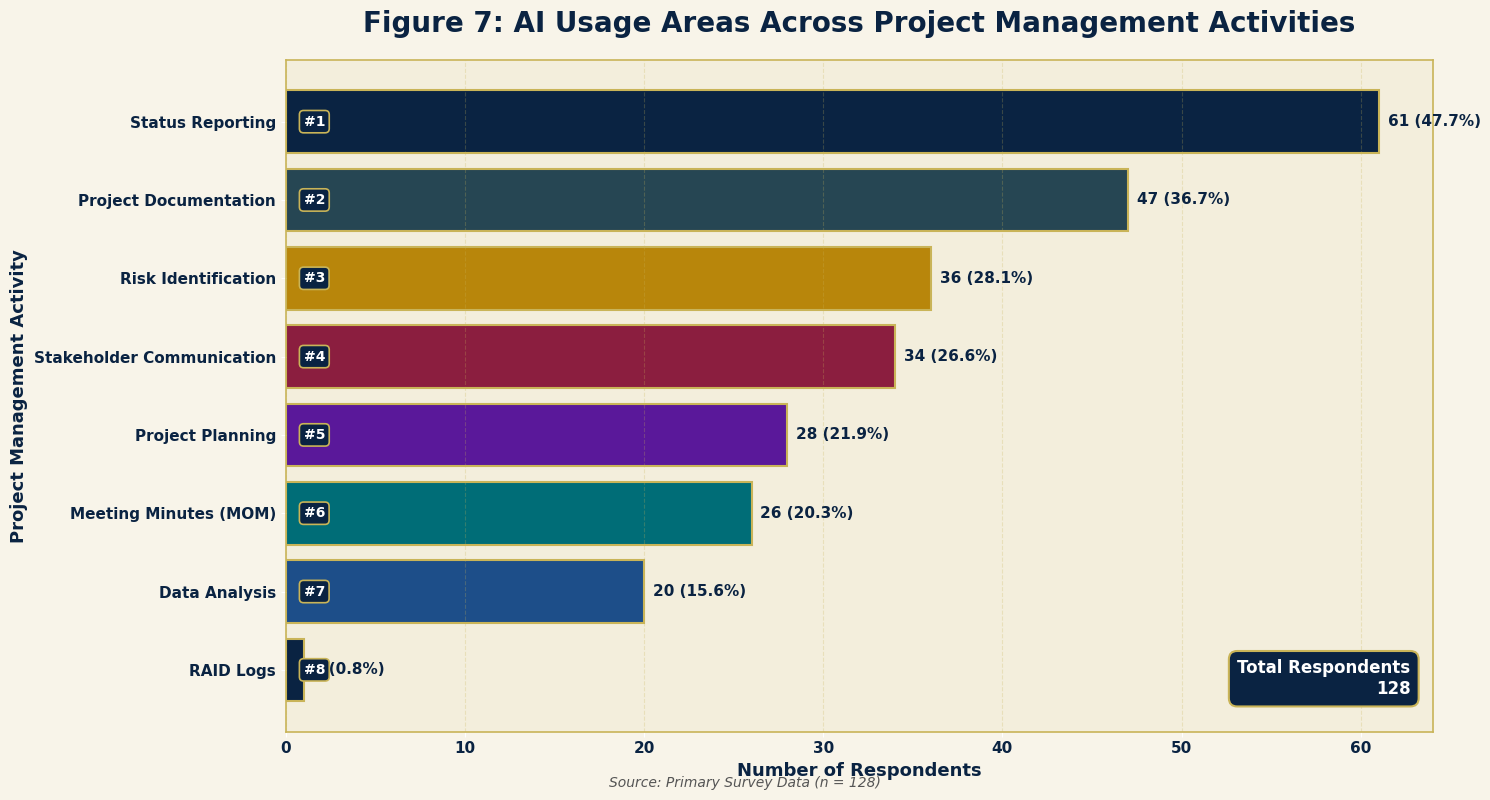

In [134]:
# ==========================================
# FIGURE 7
# AI USAGE AREAS ANALYSIS
# Premium Executive Version
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------
# Theme
# --------------------------------

PRIMARY_NAVY = "#0A2342"
ROYAL_BLUE   = "#1D4E89"
TEAL         = "#006D77"
PURPLE       = "#5A189A"
BURGUNDY     = "#8B1E3F"
GOLD         = "#B8860B"
SLATE        = "#264653"

BONE_WHITE   = "#F8F4E9"
IVORY        = "#F3EEDC"
LIME_GOLD    = "#C9B458"

THEME = [
    PRIMARY_NAVY,
    ROYAL_BLUE,
    TEAL,
    PURPLE,
    BURGUNDY,
    GOLD,
    SLATE
]

# --------------------------------
# Figure
# --------------------------------

fig, ax = plt.subplots(
    figsize=(15,8),
    facecolor=BONE_WHITE
)

ax.set_facecolor(IVORY)

colors = (THEME * 3)[:len(activity_counts)]

bars = ax.barh(
    activity_counts.index,
    activity_counts.values,
    color=colors,
    edgecolor=LIME_GOLD,
    linewidth=1.5
)

# --------------------------------
# Labels
# --------------------------------

for bar, pct in zip(bars, activity_percent):

    count = bar.get_width()

    ax.text(
        count + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{int(count)} ({pct:.1f}%)",
        va='center',
        fontsize=11,
        fontweight='bold',
        color=PRIMARY_NAVY
    )

# --------------------------------
# Ranking Badges
# --------------------------------

ranked = activity_counts.sort_values(
    ascending=False
)

for rank, (activity, value) in enumerate(
    ranked.items(),
    start=1
):

    idx = list(activity_counts.index).index(activity)

    ax.text(
        1,
        idx,
        f"#{rank}",
        va='center',
        fontsize=10,
        fontweight='bold',
        color='white',
        bbox=dict(
            facecolor=PRIMARY_NAVY,
            edgecolor=LIME_GOLD,
            linewidth=1.2,
            boxstyle='round,pad=0.3'
        )
    )

# --------------------------------
# KPI Card
# --------------------------------

ax.text(
    0.98,
    0.05,
    f"Total Respondents\n{total}",
    transform=ax.transAxes,
    ha='right',
    va='bottom',
    fontsize=12,
    fontweight='bold',
    color='white',
    bbox=dict(
        facecolor=PRIMARY_NAVY,
        edgecolor=LIME_GOLD,
        linewidth=1.5,
        boxstyle='round,pad=0.5'
    )
)

# --------------------------------
# Titles
# --------------------------------

plt.title(
    "Figure 7: AI Usage Areas Across Project Management Activities",
    fontsize=20,
    fontweight='bold',
    color=PRIMARY_NAVY,
    pad=20
)

plt.xlabel(
    "Number of Respondents",
    fontsize=13,
    fontweight='bold',
    color=PRIMARY_NAVY
)

plt.ylabel(
    "Project Management Activity",
    fontsize=13,
    fontweight='bold',
    color=PRIMARY_NAVY
)

# --------------------------------
# Grid
# --------------------------------

plt.grid(
    axis='x',
    linestyle='--',
    color=LIME_GOLD,
    alpha=0.25
)

# --------------------------------
# Axis Styling
# --------------------------------

plt.xticks(
    fontsize=11,
    fontweight='bold',
    color=PRIMARY_NAVY
)

plt.yticks(
    fontsize=11,
    fontweight='bold',
    color=PRIMARY_NAVY
)

# --------------------------------
# Border Styling
# --------------------------------

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color(LIME_GOLD)
    spine.set_linewidth(1.2)

# --------------------------------
# Footer
# --------------------------------

plt.figtext(
    0.5,
    0.01,
    "Source: Primary Survey Data (n = 128)",
    ha='center',
    fontsize=10,
    style='italic',
    color="#555555"
)

plt.tight_layout()

plt.show()

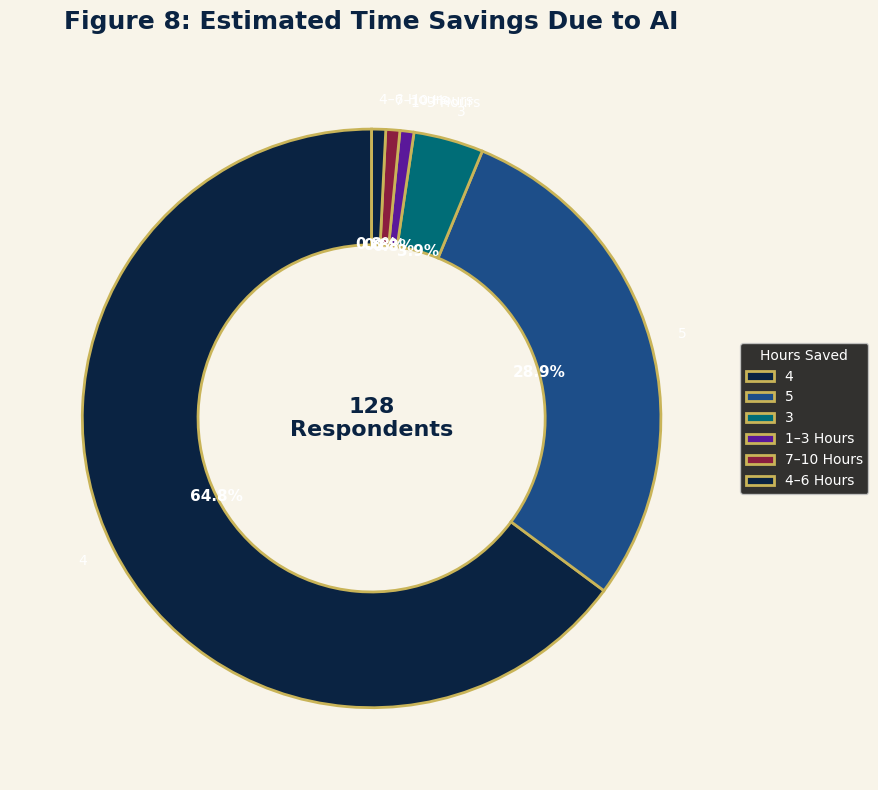

In [137]:
# ==========================================
# FIGURE 8
# ESTIMATED TIME SAVINGS DUE TO AI
# Premium Executive Donut Chart
# ==========================================

import matplotlib.pyplot as plt

# --------------------------------
# Theme
# --------------------------------

PRIMARY_NAVY = "#0A2342"
ROYAL_BLUE   = "#1D4E89"
TEAL         = "#006D77"
PURPLE       = "#5A189A"
BURGUNDY     = "#8B1E3F"

BONE_WHITE   = "#F8F4E9"
IVORY        = "#F3EEDC"
LIME_GOLD    = "#C9B458"

# --------------------------------
# Data
# --------------------------------

time_col = "Estimated Time Saved Per Week Using AI"

time_counts = (
    df[time_col]
    .value_counts()
)

total = time_counts.sum()

colors = [
    PRIMARY_NAVY,
    ROYAL_BLUE,
    TEAL,
    PURPLE,
    BURGUNDY
]

# --------------------------------
# Figure
# --------------------------------

fig, ax = plt.subplots(
    figsize=(10,8),
    facecolor=BONE_WHITE
)

ax.set_facecolor(IVORY)

wedges, texts, autotexts = ax.pie(
    time_counts.values,
    labels=time_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors[:len(time_counts)],
    wedgeprops=dict(
        width=0.40,
        edgecolor=LIME_GOLD,
        linewidth=2
    )
)

# --------------------------------
# Percentage Styling
# --------------------------------

for text in autotexts:

    text.set_fontsize(11)
    text.set_fontweight('bold')
    text.set_color('white')

# --------------------------------
# Center KPI
# --------------------------------

ax.text(
    0,
    0,
    f"{total}\nRespondents",
    ha='center',
    va='center',
    fontsize=16,
    fontweight='bold',
    color=PRIMARY_NAVY
)

# --------------------------------
# Title
# --------------------------------

plt.title(
    "Figure 8: Estimated Time Savings Due to AI",
    fontsize=18,
    fontweight='bold',
    color=PRIMARY_NAVY,
    pad=20
)

# --------------------------------
# Legend
# --------------------------------

plt.legend(
    time_counts.index,
    title="Hours Saved",
    loc="center left",
    bbox_to_anchor=(1,0.5)
)

plt.tight_layout()
plt.show()

In [141]:
time_col = "Estimated Time Saved Per Week Using AI "

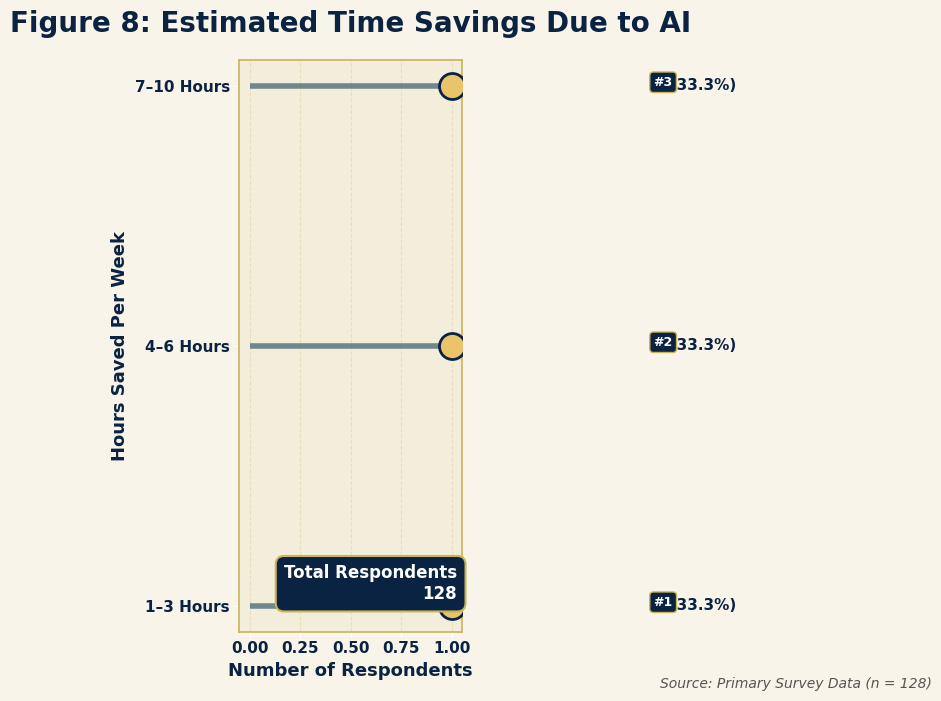

In [143]:
# ==========================================
# FIGURE 8
# ESTIMATED TIME SAVINGS DUE TO AI
# Premium Executive Lollipop Chart
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --------------------------------
# Premium MBA Theme
# --------------------------------

PRIMARY = "#0A2342"      # Navy
SECONDARY = "#4F6D7A"    # Slate Blue
SUCCESS = "#2A9D8F"      # Emerald Teal
ACCENT = "#E9C46A"       # Soft Gold
WARM = "#D4A373"         # Sandstone
BACKGROUND = "#F8F4E9"   # Bone White
BORDER = "#C9B458"       # Lime Gold
PANEL = "#F3EEDC"        # Ivory

# --------------------------------
# Data
# --------------------------------

time_col = "Estimated Time Saved Per Week Using AI"

time_counts = (
    df[time_col]
    .value_counts()
)

# Custom order
desired_order = [
    "1–3 Hours",
    "4–6 Hours",
    "7–10 Hours",
    "10+ Hours"
]

time_counts = (
    time_counts
    .reindex(
        [x for x in desired_order if x in time_counts.index]
    )
)

time_pct = (
    time_counts / time_counts.sum() * 100
).round(1)

# --------------------------------
# Figure
# --------------------------------

fig, ax = plt.subplots(
    figsize=(14,7),
    facecolor=BACKGROUND
)

ax.set_facecolor(PANEL)

# --------------------------------
# Lollipop Lines
# --------------------------------

for i, value in enumerate(time_counts):

    ax.hlines(
        y=i,
        xmin=0,
        xmax=value,
        color=SECONDARY,
        linewidth=4,
        alpha=0.8
    )

# --------------------------------
# Lollipop Dots
# --------------------------------

ax.scatter(
    time_counts.values,
    np.arange(len(time_counts)),
    s=350,
    color=ACCENT,
    edgecolors=PRIMARY,
    linewidths=2,
    zorder=3
)

# --------------------------------
# Data Labels
# --------------------------------

for i, (value, pct) in enumerate(
    zip(
        time_counts.values,
        time_pct.values
    )
):

    ax.text(
        value + 1,
        i,
        f"{value} ({pct:.1f}%)",
        va='center',
        fontsize=11,
        fontweight='bold',
        color=PRIMARY
    )

# --------------------------------
# Ranking Badges
# --------------------------------

ranked = (
    time_counts
    .sort_values(
        ascending=False
    )
)

for rank, (category, value) in enumerate(
    ranked.items(),
    start=1
):

    idx = list(time_counts.index).index(category)

    ax.text(
        2,
        idx,
        f"#{rank}",
        color="white",
        fontsize=9,
        fontweight="bold",
        bbox=dict(
            facecolor=PRIMARY,
            edgecolor=BORDER,
            boxstyle="round,pad=0.3"
        )
    )

# --------------------------------
# KPI Card
# --------------------------------

ax.text(
    0.98,
    0.05,
    f"Total Respondents\n{len(df)}",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=12,
    fontweight="bold",
    color="white",
    bbox=dict(
        facecolor=PRIMARY,
        edgecolor=BORDER,
        linewidth=1.5,
        boxstyle="round,pad=0.5"
    )
)

# --------------------------------
# Titles
# --------------------------------

plt.title(
    "Figure 8: Estimated Time Savings Due to AI",
    fontsize=20,
    fontweight="bold",
    color=PRIMARY,
    pad=20
)

plt.xlabel(
    "Number of Respondents",
    fontsize=13,
    fontweight="bold",
    color=PRIMARY
)

plt.ylabel(
    "Hours Saved Per Week",
    fontsize=13,
    fontweight="bold",
    color=PRIMARY
)

# --------------------------------
# Axis Styling
# --------------------------------

plt.yticks(
    np.arange(len(time_counts)),
    time_counts.index,
    fontsize=11,
    fontweight="bold",
    color=PRIMARY
)

plt.xticks(
    fontsize=11,
    fontweight="bold",
    color=PRIMARY
)

# --------------------------------
# Grid
# --------------------------------

plt.grid(
    axis='x',
    linestyle='--',
    color=BORDER,
    alpha=0.25
)

# --------------------------------
# Border Styling
# --------------------------------

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color(BORDER)
    spine.set_linewidth(1.2)

# --------------------------------
# Footer
# --------------------------------

plt.figtext(
    0.5,
    0.01,
    "Source: Primary Survey Data (n = 128)",
    ha='center',
    fontsize=10,
    style='italic',
    color="#555555"
)

plt.tight_layout()

plt.show()

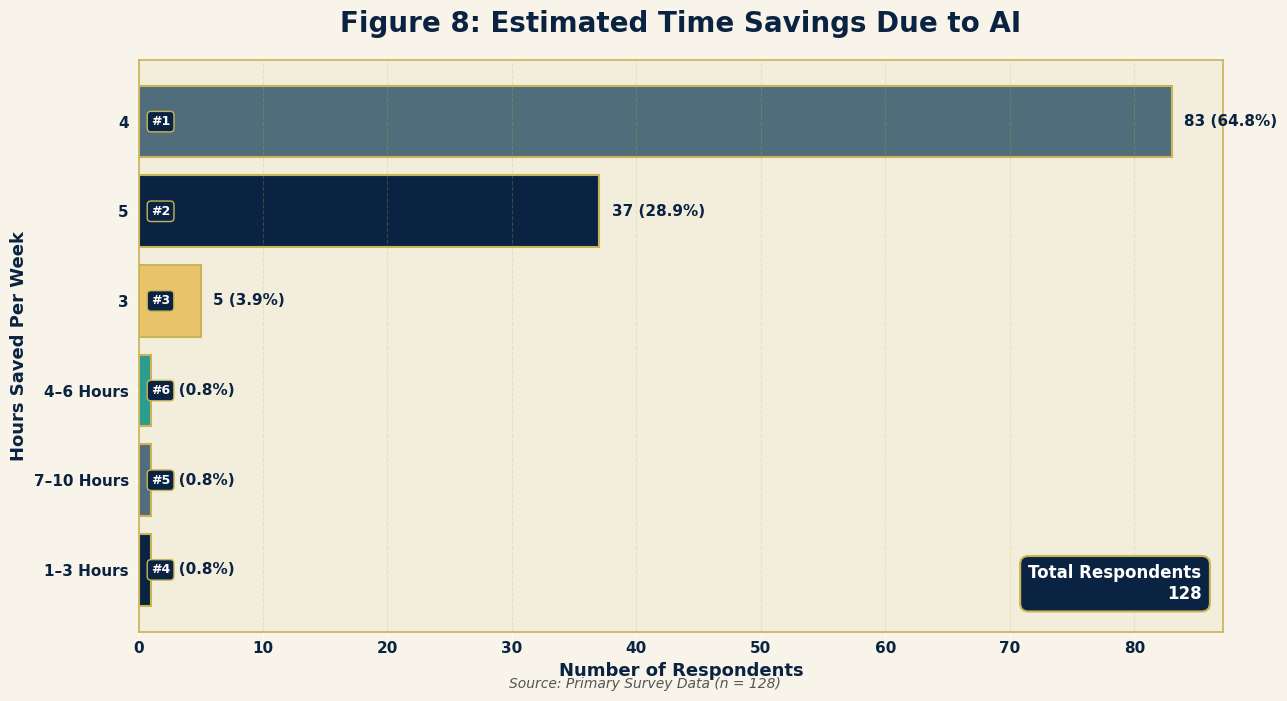

In [149]:
# ==========================================
# FIGURE 8
# ESTIMATED TIME SAVINGS DUE TO AI
# Premium Executive Horizontal Bar Chart
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------
# Theme
# --------------------------------

PRIMARY_NAVY = "#0A2342"
ROYAL_BLUE   = "#4F6D7A"
TEAL         = "#2A9D8F"
GOLD         = "#E9C46A"

BONE_WHITE   = "#F8F4E9"
IVORY        = "#F3EEDC"
LIME_GOLD    = "#C9B458"

# --------------------------------
# Data
# --------------------------------

time_col = "Estimated Time Saved Per Week Using AI"

time_counts = (
    df[time_col]
    .value_counts()
    .sort_values()
)

total = time_counts.sum()

time_pct = (
    time_counts / total * 100
).round(1)

# --------------------------------
# Figure
# --------------------------------

fig, ax = plt.subplots(
    figsize=(13,7),
    facecolor=BONE_WHITE
)

ax.set_facecolor(IVORY)

# --------------------------------
# Premium Colors
# --------------------------------

colors = [
    PRIMARY_NAVY,
    ROYAL_BLUE,
    TEAL,
    GOLD
]

bars = ax.barh(
    time_counts.index,
    time_counts.values,
    color=colors[:len(time_counts)],
    edgecolor=LIME_GOLD,
    linewidth=1.5
)

# --------------------------------
# Data Labels
# --------------------------------

for bar, pct in zip(bars, time_pct):

    value = bar.get_width()

    ax.text(
        value + 1,
        bar.get_y() + bar.get_height()/2,
        f"{int(value)} ({pct:.1f}%)",
        va='center',
        fontsize=11,
        fontweight='bold',
        color=PRIMARY_NAVY
    )

# --------------------------------
# Ranking Badges
# --------------------------------

ranked = (
    time_counts
    .sort_values(ascending=False)
)

for rank, (category, value) in enumerate(
    ranked.items(),
    start=1
):

    idx = list(time_counts.index).index(category)

    ax.text(
        1,
        idx,
        f"#{rank}",
        va='center',
        fontsize=9,
        fontweight='bold',
        color='white',
        bbox=dict(
            facecolor=PRIMARY_NAVY,
            edgecolor=LIME_GOLD,
            boxstyle='round,pad=0.3'
        )
    )

# --------------------------------
# KPI Card
# --------------------------------

ax.text(
    0.98,
    0.05,
    f"Total Respondents\n{total}",
    transform=ax.transAxes,
    ha='right',
    va='bottom',
    fontsize=12,
    fontweight='bold',
    color='white',
    bbox=dict(
        facecolor=PRIMARY_NAVY,
        edgecolor=LIME_GOLD,
        linewidth=1.5,
        boxstyle='round,pad=0.5'
    )
)

# --------------------------------
# Title
# --------------------------------

plt.title(
    "Figure 8: Estimated Time Savings Due to AI",
    fontsize=20,
    fontweight='bold',
    color=PRIMARY_NAVY,
    pad=20
)

# --------------------------------
# Axis Labels
# --------------------------------

plt.xlabel(
    "Number of Respondents",
    fontsize=13,
    fontweight='bold',
    color=PRIMARY_NAVY
)

plt.ylabel(
    "Hours Saved Per Week",
    fontsize=13,
    fontweight='bold',
    color=PRIMARY_NAVY
)

# --------------------------------
# Grid
# --------------------------------

plt.grid(
    axis='x',
    linestyle='--',
    color=LIME_GOLD,
    alpha=0.25
)

# --------------------------------
# Axis Styling
# --------------------------------

plt.xticks(
    fontsize=11,
    fontweight='bold',
    color=PRIMARY_NAVY
)

plt.yticks(
    fontsize=11,
    fontweight='bold',
    color=PRIMARY_NAVY
)

# --------------------------------
# Border Styling
# --------------------------------

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color(LIME_GOLD)
    spine.set_linewidth(1.2)

# --------------------------------
# Footer
# --------------------------------

plt.figtext(
    0.5,
    0.01,
    f"Source: Primary Survey Data (n = {total})",
    ha='center',
    fontsize=10,
    style='italic',
    color="#555555"
)

sns.despine(
    top=False,
    right=False
)

plt.tight_layout()
plt.show()

IndexError: index 0 is out of bounds for axis 0 with size 0

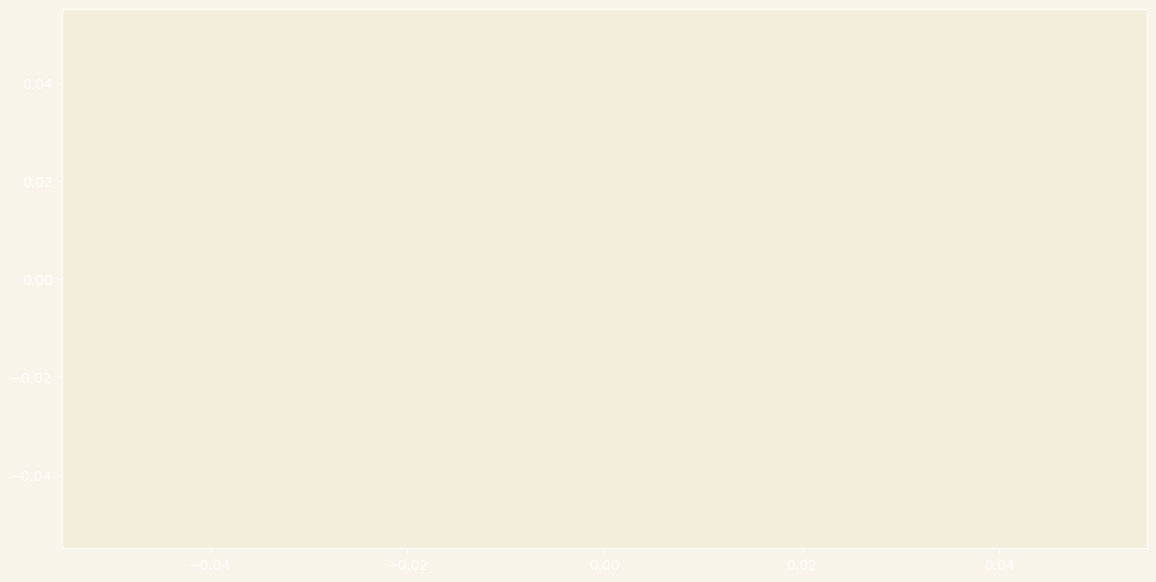

In [161]:
# ==========================================
# FIGURE 9
# ESTIMATED PRODUCTIVITY IMPROVEMENT DUE TO AI
# Premium Executive Horizontal Bar Chart
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------
# Theme
# --------------------------------

PRIMARY = "#0A2342"      # Navy
SECONDARY = "#4F6D7A"    # Slate Blue
SUCCESS = "#2A9D8F"      # Emerald Teal
ACCENT = "#E9C46A"       # Soft Gold
WARM = "#D4A373"         # Sandstone

BACKGROUND = "#F8F4E9"  # Bone White
PANEL = "#F3EEDC"       # Ivory
BORDER = "#C9B458"      # Lime Gold

# --------------------------------
# Data
# --------------------------------

prod_col = "Estimated Productivity Improvement Due to AI"

prod_counts = (
    df[prod_col]
    .value_counts()
)

# Logical order

desired_order = [
    "0-10%",
    "11-20%",
    "21-30%",
    "31-40%",
    "41-50%",
    "50%+"
]

available = [
    x for x in desired_order
    if x in prod_counts.index
]

prod_counts = (
    prod_counts
    .reindex(available)
    .sort_values()
)

total = prod_counts.sum()

prod_pct = (
    prod_counts / total * 100
).round(1)

# --------------------------------
# Figure
# --------------------------------

fig, ax = plt.subplots(
    figsize=(14,7),
    facecolor=BACKGROUND
)

ax.set_facecolor(PANEL)

# --------------------------------
# Colors
# --------------------------------

colors = [
    PRIMARY,
    SECONDARY,
    SUCCESS,
    ACCENT,
    WARM
]

bars = ax.barh(
    prod_counts.index,
    prod_counts.values,
    color=colors[:len(prod_counts)],
    edgecolor=BORDER,
    linewidth=1.5
)

# --------------------------------
# Data Labels
# --------------------------------

for bar, pct in zip(
    bars,
    prod_pct
):

    value = bar.get_width()

    ax.text(
        value + 1,
        bar.get_y() + bar.get_height()/2,
        f"{int(value)} ({pct:.1f}%)",
        va='center',
        fontsize=11,
        fontweight='bold',
        color=PRIMARY
    )

# --------------------------------
# Ranking Badges
# --------------------------------

ranked = (
    prod_counts
    .sort_values(
        ascending=False
    )
)

for rank, (category, value) in enumerate(
    ranked.items(),
    start=1
):

    idx = list(prod_counts.index).index(category)

    ax.text(
        1,
        idx,
        f"#{rank}",
        va='center',
        fontsize=9,
        fontweight='bold',
        color='white',
        bbox=dict(
            facecolor=PRIMARY,
            edgecolor=BORDER,
            boxstyle='round,pad=0.3'
        )
    )

# --------------------------------
# KPI Card
# --------------------------------

top_category = ranked.index[0]

ax.text(
    0.98,
    0.05,
    f"Top Category\n{top_category}",
    transform=ax.transAxes,
    ha='right',
    va='bottom',
    fontsize=12,
    fontweight='bold',
    color='white',
    bbox=dict(
        facecolor=PRIMARY,
        edgecolor=BORDER,
        linewidth=1.5,
        boxstyle='round,pad=0.5'
    )
)

# --------------------------------
# Titles
# --------------------------------

plt.title(
    "Figure 9: Estimated Productivity Improvement Due to AI",
    fontsize=20,
    fontweight='bold',
    color=PRIMARY,
    pad=20
)

plt.xlabel(
    "Number of Respondents",
    fontsize=13,
    fontweight='bold',
    color=PRIMARY
)

plt.ylabel(
    "Estimated Productivity Improvement",
    fontsize=13,
    fontweight='bold',
    color=PRIMARY
)

# --------------------------------
# Grid
# --------------------------------

plt.grid(
    axis='x',
    linestyle='--',
    color=BORDER,
    alpha=0.25
)

# --------------------------------
# Axis Styling
# --------------------------------

plt.xticks(
    fontsize=11,
    fontweight='bold',
    color=PRIMARY
)

plt.yticks(
    fontsize=11,
    fontweight='bold',
    color=PRIMARY
)

# --------------------------------
# Border Styling
# --------------------------------

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color(BORDER)
    spine.set_linewidth(1.2)

# --------------------------------
# Footer
# --------------------------------

plt.figtext(
    0.5,
    0.01,
    f"Source: Primary Survey Data (n = {total})",
    ha='center',
    fontsize=10,
    style='italic',
    color="#555555"
)

sns.despine(
    top=False,
    right=False
)

plt.tight_layout()
plt.show()

In [152]:
available = [
    x for x in desired_order
    if x in prod_counts.index
]

In [155]:
for col in df.columns:
    if "productivity" in col.lower():
        print(col)

Generative AI increases overall productivity.
Estimated Productivity Improvement Due to AI
Productivity_Index


In [158]:
prod_col = "Estimated Productivity Improvement Due to AI"

print(df[prod_col].head())
print(df[prod_col].isna().sum())
print(df[prod_col].value_counts(dropna=False))

0    11–20%
1    21–30%
2    21–30%
3         5
4         5
Name: Estimated Productivity Improvement Due to AI, dtype: object
0
Estimated Productivity Improvement Due to AI
4         66
5         53
3          6
21–30%     2
11–20%     1
Name: count, dtype: int64


In [159]:
prod_counts = (
    df[prod_col]
    .dropna()
    .value_counts()
)

print(prod_counts)
print("Length:", len(prod_counts))

Estimated Productivity Improvement Due to AI
4         66
5         53
3          6
21–30%     2
11–20%     1
Name: count, dtype: int64
Length: 5


In [160]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 33 columns):
 #   Column                                                                                  Non-Null Count  Dtype  
---  ------                                                                                  --------------  -----  
 0   Timestamp                                                                               128 non-null    object 
 1   What is your current role?                                                              128 non-null    object 
 2   How many years of professional experience do you have?                                  128 non-null    object 
 3   Which function do you primarily work in?                                                128 non-null    object 
 4   Which industry does your organization belong to?                                        128 non-null    object 
 5   Which Generative AI tool do you use most frequently?                   

In [162]:
print(df.columns.tolist())
df.count()

['Timestamp', 'What is your current role?', 'How many years of professional experience do you have?', 'Which function do you primarily work in?', 'Which industry does your organization belong to?', 'Which Generative AI tool do you use most frequently?', 'How frequently do you use Generative AI in your work?', 'Approximately what percentage of your work activities are supported by AI?', 'Which project management activities do you use AI for? (Select all that apply)', 'Generative AI reduces the effort required for project documentation.', 'Generative AI improves the quality of project reports and presentations.', 'Generative AI accelerates meeting summary and MOM preparation.', 'Generative AI improves decision-making speed.', 'Generative AI reduces repetitive administrative work.', 'Generative AI increases overall productivity.', 'Generative AI will significantly transform PMO and project delivery operations.', 'Generative AI improves stakeholder communication effectiveness.', 'Generativ

,0
Timestamp,128
What is your current role?,128
How many years of professional experience do you have?,128
Which function do you primarily work in?,128
Which industry does your organization belong to?,128
Which Generative AI tool do you use most frequently?,128
How frequently do you use Generative AI in your work?,128
Approximately what percentage of your work activities are supported by AI?,128
Which project management activities do you use AI for? (Select all that apply),128
Generative AI reduces the effort required for project documentation.,68


In [163]:
prod_col = "Estimated Productivity Improvement Due to AI"

prod_counts = (
    df[prod_col]
    .dropna()
    .value_counts()
    .sort_values()
)

print(prod_counts)


Estimated Productivity Improvement Due to AI
11–20%     1
21–30%     2
3          6
5         53
4         66
Name: count, dtype: int64


In [164]:
total = prod_counts.sum()

prod_pct = (
    prod_counts / total * 100
).round(1)

ranked = prod_counts.sort_values(
    ascending=False
)

top_category = ranked.index[0]

In [165]:
prod_col = "Estimated Productivity Improvement Due to AI"

prod_counts = (
    df[prod_col]
    .dropna()
    .value_counts()
)

if len(prod_counts) == 0:
    raise ValueError("No productivity improvement data found.")

total = prod_counts.sum()

prod_pct = (
    prod_counts / total * 100
).round(1)

ranked = prod_counts.sort_values(
    ascending=False
)

top_category = ranked.index[0]

In [168]:
# --------------------------------
# Data
# --------------------------------

prod_col = "Estimated Productivity Improvement Due to AI"

prod_counts = (
    df[prod_col]
    .dropna()
    .value_counts()
)

total = len(df)

prod_pct = (
    prod_counts / total * 100
).round(1)

# Sort by percentage
prod_pct = prod_pct.sort_values()

ranked = prod_pct.sort_values(
    ascending=False
)

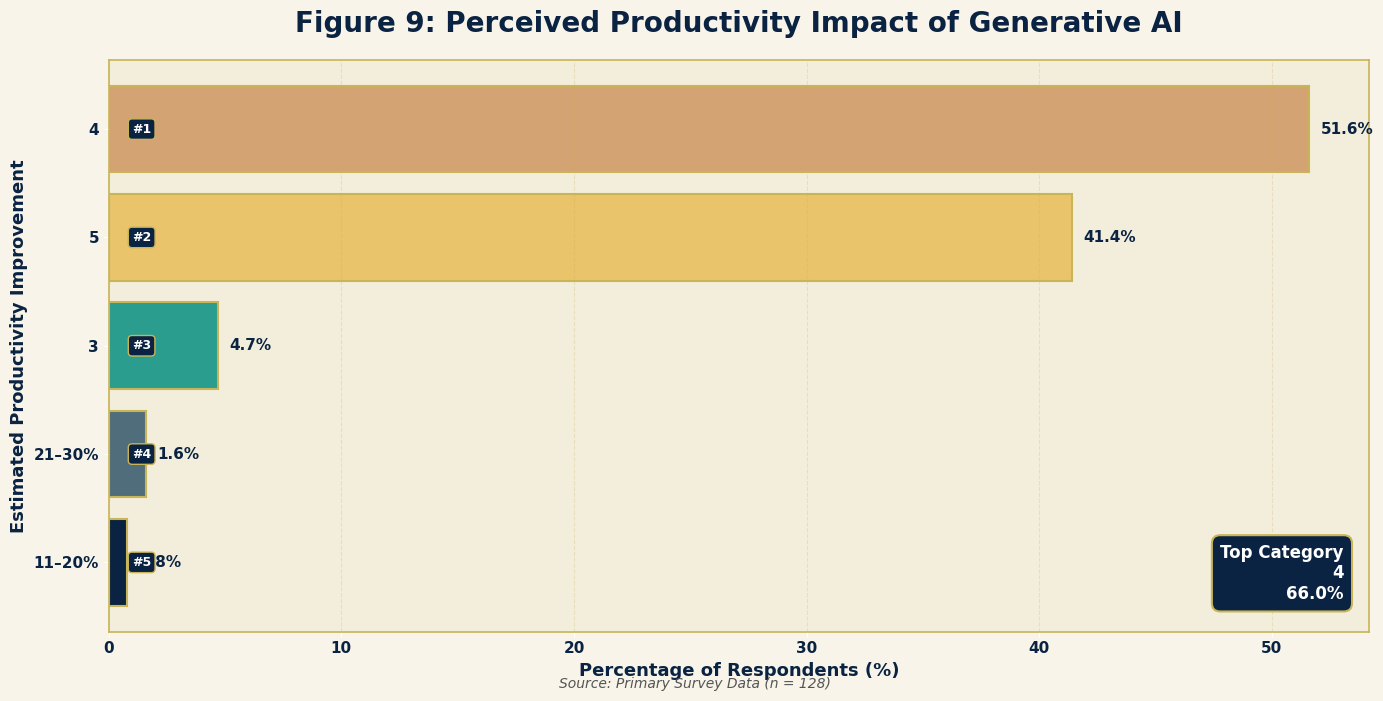

In [170]:
rating_map = {
    "3": "Moderate Impact",
    "4": "High Impact",
    "5": "Very High Impact"
}
# ==========================================
# FIGURE 9
# ESTIMATED PRODUCTIVITY IMPROVEMENT DUE TO AI
# Premium Executive Horizontal Bar Chart
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------
# Premium Theme
# --------------------------------

PRIMARY = "#0A2342"      # Midnight Navy
SECONDARY = "#4F6D7A"    # Slate Blue
SUCCESS = "#2A9D8F"      # Emerald Teal
ACCENT = "#E9C46A"       # Soft Gold
WARM = "#D4A373"         # Sandstone

BACKGROUND = "#F8F4E9"  # Bone White
PANEL = "#F3EEDC"       # Ivory
BORDER = "#C9B458"      # Lime Gold

# --------------------------------
# Data
# --------------------------------

prod_col = "Estimated Productivity Improvement Due to AI"

prod_counts = (
    df[prod_col]
    .dropna()
    .value_counts()
    .sort_values()
)

total = prod_counts.sum()

prod_pct = (
    prod_counts / total * 100
).round(1)

# --------------------------------
# Figure
# --------------------------------

fig, ax = plt.subplots(
    figsize=(14,7),
    facecolor=BACKGROUND
)

ax.set_facecolor(PANEL)

# --------------------------------
# Color Palette
# --------------------------------

colors = [
    PRIMARY,
    SECONDARY,
    SUCCESS,
    ACCENT,
    WARM
]

bars = ax.barh(
    prod_pct.index,
    prod_pct.values,
    color=colors[:len(prod_pct)],
    edgecolor=BORDER,
    linewidth=1.5
)

# --------------------------------
# Data Labels
# --------------------------------
for bar in bars:

    value = bar.get_width()

    ax.text(
        value + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{value:.1f}%",
        va='center',
        fontsize=11,
        fontweight='bold',
        color=PRIMARY
    )

# --------------------------------
# Ranking Badges
# --------------------------------

ranked = prod_counts.sort_values(
    ascending=False
)

for rank, (category, value) in enumerate(
    ranked.items(),
    start=1
):

    idx = list(prod_counts.index).index(category)

    ax.text(
        1,
        idx,
        f"#{rank}",
        va='center',
        fontsize=9,
        fontweight='bold',
        color='white',
        bbox=dict(
            facecolor=PRIMARY,
            edgecolor=BORDER,
            boxstyle='round,pad=0.3'
        )
    )

# --------------------------------
# KPI Card
# --------------------------------

top_category = ranked.index[0]
top_value = ranked.iloc[0]

ax.text(
    0.98,
    0.05,
    f"Top Category\n{top_category}\n{top_value:.1f}%",
    transform=ax.transAxes,
    ha='right',
    va='bottom',
    fontsize=12,
    fontweight='bold',
    color='white',
    bbox=dict(
        facecolor=PRIMARY,
        edgecolor=BORDER,
        linewidth=1.5,
        boxstyle='round,pad=0.5'
    )
)

# --------------------------------
# Titles
# --------------------------------

plt.title(
    "Figure 9: Perceived Productivity Impact of Generative AI",
    fontsize=20,
    fontweight='bold',
    color=PRIMARY,
    pad=20
)

plt.xlabel(
    "Percentage of Respondents (%)",
    fontsize=13,
    fontweight='bold',
    color=PRIMARY
)

plt.ylabel(
    "Estimated Productivity Improvement",
    fontsize=13,
    fontweight='bold',
    color=PRIMARY
)

# --------------------------------
# Axis Styling
# --------------------------------

plt.xticks(
    fontsize=11,
    fontweight='bold',
    color=PRIMARY
)

plt.yticks(
    fontsize=11,
    fontweight='bold',
    color=PRIMARY
)

# --------------------------------
# Grid
# --------------------------------

plt.grid(
    axis='x',
    linestyle='--',
    color=BORDER,
    alpha=0.25
)

# --------------------------------
# Border Styling
# --------------------------------

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color(BORDER)
    spine.set_linewidth(1.2)

# --------------------------------
# Footer
# --------------------------------

plt.figtext(
    0.5,
    0.01,
    f"Source: Primary Survey Data (n = {total})",
    ha='center',
    fontsize=10,
    style='italic',
    color="#555555"
)

sns.despine(
    top=False,
    right=False
)

plt.tight_layout()
plt.show()

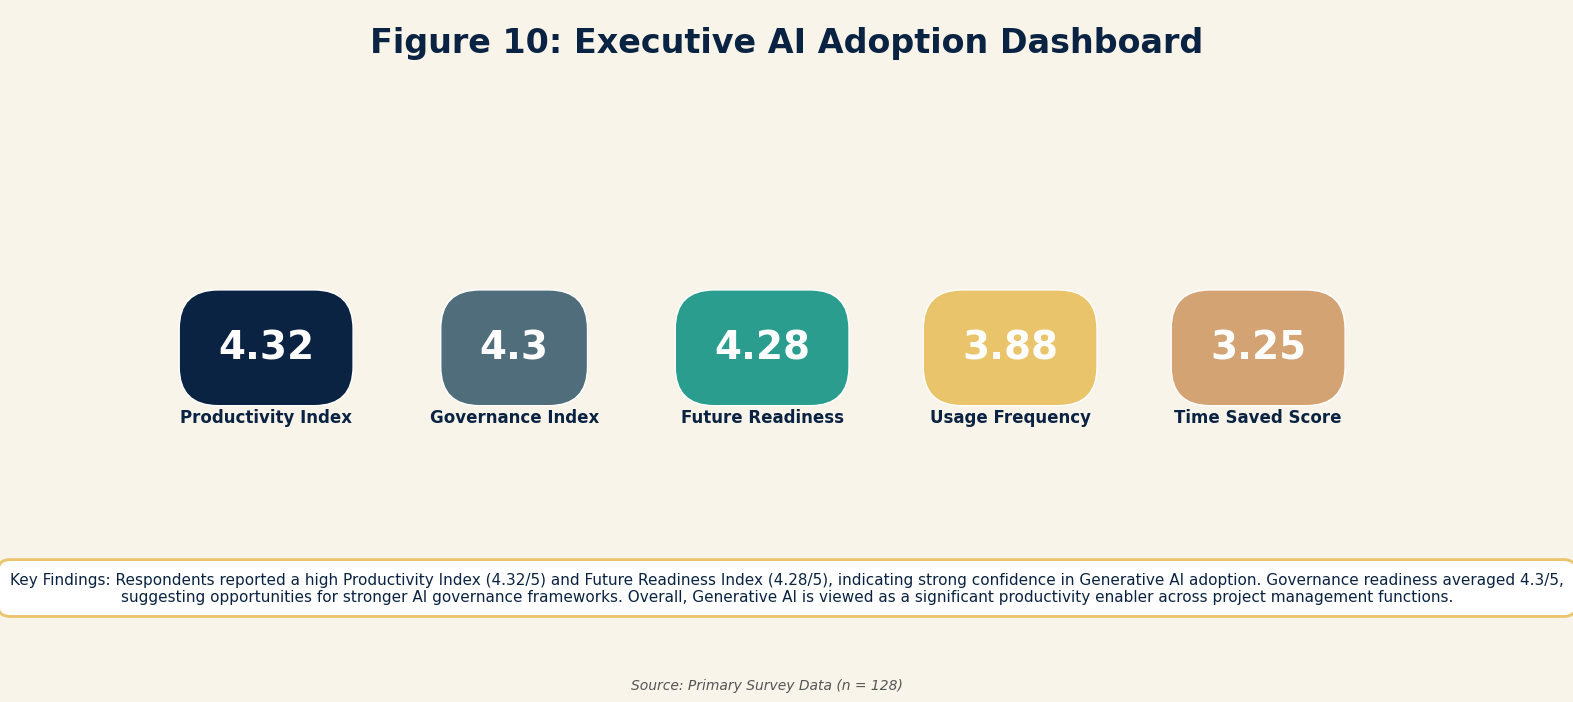

In [172]:
# ==========================================
# FIGURE 10
# EXECUTIVE AI ADOPTION DASHBOARD
# Premium MBA Version
# ==========================================

import matplotlib.pyplot as plt

# --------------------------------
# Theme
# --------------------------------

PRIMARY = "#0A2342"
SECONDARY = "#4F6D7A"
SUCCESS = "#2A9D8F"
ACCENT = "#E9C46A"
WARM = "#D4A373"

BACKGROUND = "#F8F4E9"

# --------------------------------
# KPIs
# --------------------------------

productivity = round(df["Productivity_Index"].mean(), 2)
governance = round(df["Governance_Index"].mean(), 2)
future_ready = round(df["Future_Readiness_Index"].mean(), 2)
frequency = round(df["Frequency_Score"].mean(), 2)
time_saved = round(df["TimeSaved_Score"].mean(), 2)

# --------------------------------
# Figure
# --------------------------------

fig = plt.figure(
    figsize=(16,8),
    facecolor=BACKGROUND
)

plt.axis("off")

# --------------------------------
# Main Title
# --------------------------------

plt.text(
    0.5,
    0.93,
    "Figure 10: Executive AI Adoption Dashboard",
    ha='center',
    fontsize=24,
    fontweight='bold',
    color=PRIMARY
)

# --------------------------------
# KPI Cards
# --------------------------------

cards = [
    ("Productivity Index", productivity, PRIMARY),
    ("Governance Index", governance, SECONDARY),
    ("Future Readiness", future_ready, SUCCESS),
    ("Usage Frequency", frequency, ACCENT),
    ("Time Saved Score", time_saved, WARM)
]

positions = [
    (0.08, 0.45),
    (0.28, 0.45),
    (0.48, 0.45),
    (0.68, 0.45),
    (0.88, 0.45)
]

for (title, value, color), (x, y) in zip(cards, positions):

    plt.text(
        x,
        y,
        f"{value}",
        ha='center',
        va='center',
        fontsize=28,
        fontweight='bold',
        color='white',
        bbox=dict(
            facecolor=color,
            edgecolor='white',
            boxstyle='round,pad=1'
        )
    )

    plt.text(
        x,
        y-0.12,
        title,
        ha='center',
        fontsize=12,
        fontweight='bold',
        color=PRIMARY
    )

# --------------------------------
# Executive Summary Box
# --------------------------------

summary = (
    f"Key Findings: Respondents reported a high Productivity Index "
    f"({productivity}/5) and Future Readiness Index ({future_ready}/5), "
    f"indicating strong confidence in Generative AI adoption. "
    f"Governance readiness averaged {governance}/5, suggesting opportunities "
    f"for stronger AI governance frameworks. Overall, Generative AI is viewed "
    f"as a significant productivity enabler across project management functions."
)

plt.text(
    0.5,
    0.06,
    summary,
    ha='center',
    va='center',
    fontsize=11,
    color=PRIMARY,
    wrap=True,
    bbox=dict(
        facecolor="white",
        edgecolor=ACCENT,
        linewidth=2,
        boxstyle='round,pad=0.8'
    )
)

# --------------------------------
# Footer
# --------------------------------

plt.figtext(
    0.5,
    0.03,
    "Source: Primary Survey Data (n = 128)",
    ha='center',
    fontsize=10,
    style='italic',
    color="#555555"
)

plt.show()